
# Stock Price Forecasting 
## Seq2Seq + Prophet + XGBoost + Ensemble

Professionally generated notebook. Select the ticker at the beginning (input) and run the cells sequentially.


### ✅ Asset Correlation Test using Top 100 Stocks Dataset

This script loads a CSV containing the Top 100 most traded stocks and uses the custom function `get_top_correlated_stocks` to analyze which assets have the highest historical correlation with a selected ticker. The results include metadata such as company name, sector, and correlation score, shown in a pandas DataFrame.




In [1]:
import sys
from pathlib import Path

# Absolute path to the CSV file
csv_path = Path().resolve() / "data" / "top100_stocks.csv"

# Add src to the system path
SRC_DIR = Path().resolve() / "src"
sys.path.append(str(SRC_DIR))

from finance_utils import get_top_correlated_stocks

# Settings
TICKER = "TSLA"
top_n = 2         # number of Assets
period = "5y"     # years

SEQ_TO_USE = 350  # last days
HORIZON = 1       # day-by-day reconstruction
SEQ_TO_USE = 350          # últimos 350 dias para análise
HORIZONS_TO_PLOT = [1, 3] # days of predict
batch_size = 64

# Execute function
results = get_top_correlated_stocks(
    ticker=TICKER,
    top_n=top_n,
    period=period,
    csv_path=csv_path  # explicitly defined!
)

# Unpack results
TICKER, ADDITIONAL, ALL_TICKERS, final_df = (
    results["ticker"],
    results["additional"],
    results["all_tickers"],
    results["final_df"]
)

print("Ticker:", TICKER)
print("Additional assets:", ADDITIONAL)
print("Available tickers:", ALL_TICKERS)
print("\nTop correlated assets:")

if "Correlation" in final_df.columns:
    display(final_df[["Ticker", "Company", "Sector", "Correlation"]].round(2))
else:
    print("\n⚠️ No correlated assets found with metadata. Check CSV columns.")
    display(final_df.head())




[*********************100%***********************]  118 of 118 completed

3 Failed downloads:
['^CRB', '^XLK', '^XLE']: YFPricesMissingError('possibly delisted; no price data found  (period=5y)')



⚠️ Tickers que falharam no download e serão removidos: ['^CRB', '^XLE', '^XLK']
Ticker: TSLA
Additional assets: ['^IXIC', 'QQQ']
Available tickers: ['TSLA', '^IXIC', 'QQQ']

Top correlated assets:


,Ticker,Company,Sector,Correlation
0,^IXIC,NASDAQ Composite,Index,0.64
1,QQQ,Invesco QQQ ETF,Index,0.64


### 🔌 Libraries and Model Imports for Time Series Forecasting

This section loads all necessary dependencies for financial time series forecasting including data manipulation, model building, scaling, performance evaluation, visualization, and optional advanced models such as Facebook Prophet and XGBoost. The code also suppresses irrelevant warnings to keep logs clean.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
import yfinance as yf
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, TimeDistributed
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Optional models
try:
    from prophet import Prophet
except:
    Prophet = None
try:
    import xgboost as xgb
except:
    xgb = None

2025-11-09 21:29:46.108735: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-09 21:29:46.313420: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-09 21:29:47.804080: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Importing plotly failed. Interactive plots will not work.


### ⚙️ Forecasting Configuration Parameters

This block defines key hyperparameters and settings used for training the forecasting model, including the input sequence length, prediction horizon, model complexity, batch size, number of epochs, and validation ratio. It also handles model output directory creation and sets random seeds for reproducibility.


In [3]:
# Params
USE_MULTIVAR = False    # True = multivariate, False = TSLA only

TICKER = results["ticker"]               # target asset
ADDITIONAL = results["additional"]       # additional assets if multivariate
ALL_TICKERS = [TICKER] + ADDITIONAL if USE_MULTIVAR else [TICKER]

SEQ_LEN = 60             # historical window (days)
HORIZON = 30             # forecasting horizon (days ahead)
LATENT_DIM = 128         # LSTM latent dimension
BATCH_SIZE = 64
EPOCHS = 60
VALIDATION_SPLIT = 0.15
OUT_DIR = "model_outputs"

os.makedirs(OUT_DIR, exist_ok=True)

np.random.seed(42)
tf.random.set_seed(42)


### 📥 Data Download, Feature Engineering & Asset Filtering

This section downloads 5 years of historical data from Yahoo Finance and builds the main feature set including prices, log returns, and volumes for the selected tickers. Asset selection is then performed based on return correlations with the target ticker to retain only relevant time series for modeling.


In [4]:
# Download historical data
print("Downloading Yahoo Finance data for:", ALL_TICKERS)
raw = yf.download(ALL_TICKERS, period="5y", auto_adjust=True, progress=False)

# Flatten MultiIndex columns if needed
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = [f"{col[1]}_{col[0]}" for col in raw.columns]

raw = raw.dropna(how='all')
raw.index.name = 'Date'

# Feature engineering
df = pd.DataFrame(index=raw.index)

for t in ALL_TICKERS:
    close_col = f"{t}_Close"
    vol_col = f"{t}_Volume"

    if close_col in raw.columns:
        df[f'{t}_price'] = raw[close_col]
        df[f'{t}_lr'] = np.log1p(raw[close_col].pct_change()).fillna(0)  # log returns

    if vol_col in raw.columns:
        df[f'{t}_vol'] = raw[vol_col].fillna(method='ffill')

df = df.dropna(how='all')

# Relevant asset selection
corr_df = df[[c for c in df.columns if c.endswith('_lr')]].corr()
corr_with_target = corr_df[f'{TICKER}_lr'].abs().sort_values(ascending=False)

KEEP = [f'{TICKER}_lr']
for idx, val in corr_with_target.items():
    if idx != f'{TICKER}_lr' and val >= 0.2:
        KEEP.append(idx)

print('Kept return assets:', KEEP)


Kept return assets: ['TSLA_lr']


### 🧩 Final Feature Construction for Time Series Modeling

This block selects the final set of predictive variables by combining price, volume, and engineered time-dependent features such as rolling mean and rolling volatility. Duplicates are removed while preserving order, and the target asset’s price feature is set as the first column to support model training. Missing values are handled using forward/backward filling.


In [5]:
# Build final features
features = []

for lr_col in KEEP:
    t = lr_col.replace('_lr', '')

    # Add base features if available
    if f'{t}_price' in df.columns:
        features.append(f'{t}_price')
    if f'{t}_vol' in df.columns:
        features.append(f'{t}_vol')

    # Rolling statistics
    df[f'{t}_rm_5'] = df[f'{t}_lr'].rolling(5).mean().fillna(0)  # 5-day rolling mean
    df[f'{t}_std_10'] = df[f'{t}_lr'].rolling(10).std().fillna(0)  # 10-day volatility estimate

    features += [f'{t}_rm_5', f'{t}_std_10']

# Remove duplicates (preserve order)
features = [v for i, v in enumerate(dict.fromkeys(features))]

# Ensure target price feature is first
if f'{TICKER}_price' in features:
    features.insert(0, features.pop(features.index(f'{TICKER}_price')))

df[features] = df[features].ffill().bfill().fillna(0)


### 📦 Scaler Training and Persistence

This block standardizes both features and target values using `StandardScaler`, then saves the trained scalers into the model output directory. These saved objects are reused during inference to ensure that new real-time inputs follow the exact same scaling applied during model training.



In [6]:
# Scalers + Persistence
y_all = df[f'{TICKER}_lr'].values.reshape(-1, 1)
X_all = df[features].values

# Standardization
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_all)
y_scaled = scaler_y.fit_transform(y_all)

# Save scalers for later inference
joblib.dump(scaler_X, os.path.join(OUT_DIR, "scaler_X.pkl"))
joblib.dump(scaler_y, os.path.join(OUT_DIR, "scaler_y.pkl"))

print("✅ Scalers saved to:", OUT_DIR)


✅ Scalers saved to: model_outputs


### 🔁 Seq2Seq Sliding Window Creation & Temporal Split

This section builds the sliding windows required for a Sequence-to-Sequence forecasting model. The encoder receives a sequence of past standardized features, while the decoder is fed the last observed target value followed by shifted future values. The final dataset is then split temporally into training and validation sets to preserve chronological integrity.

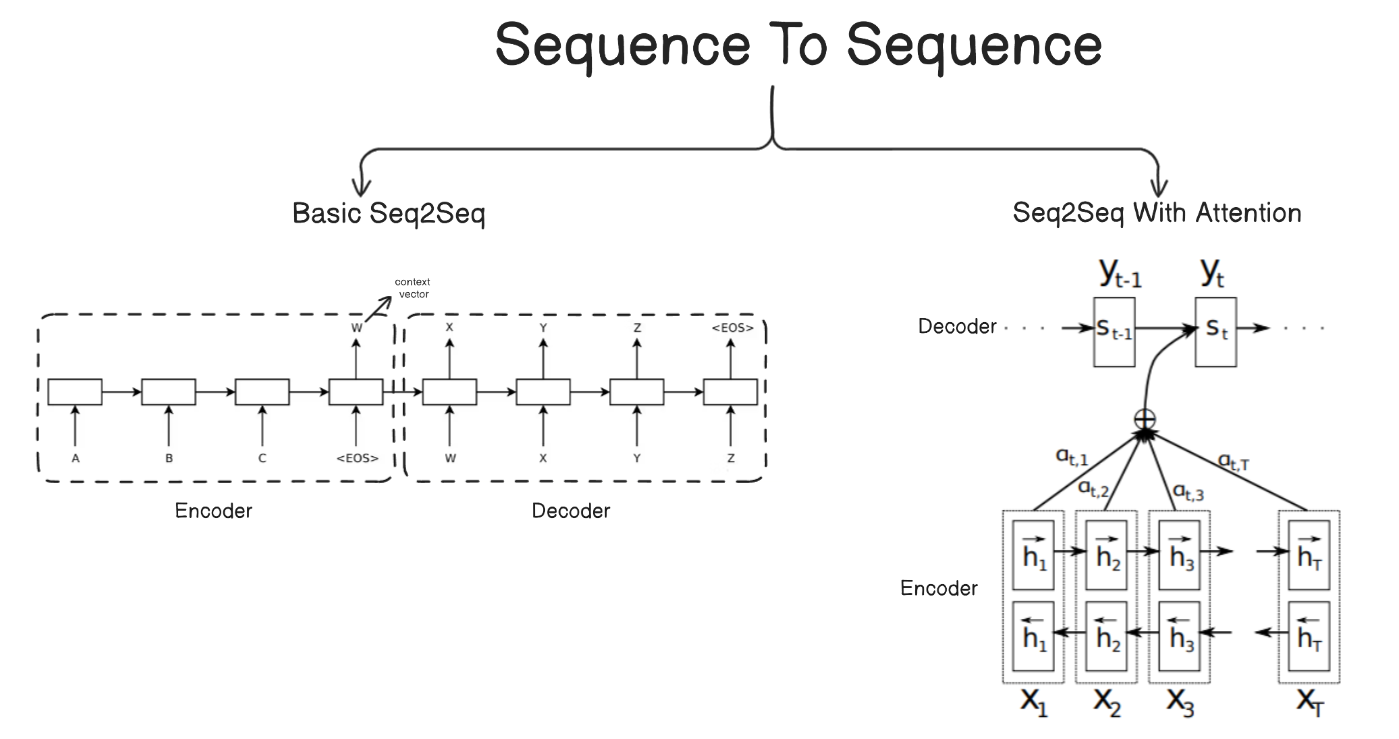
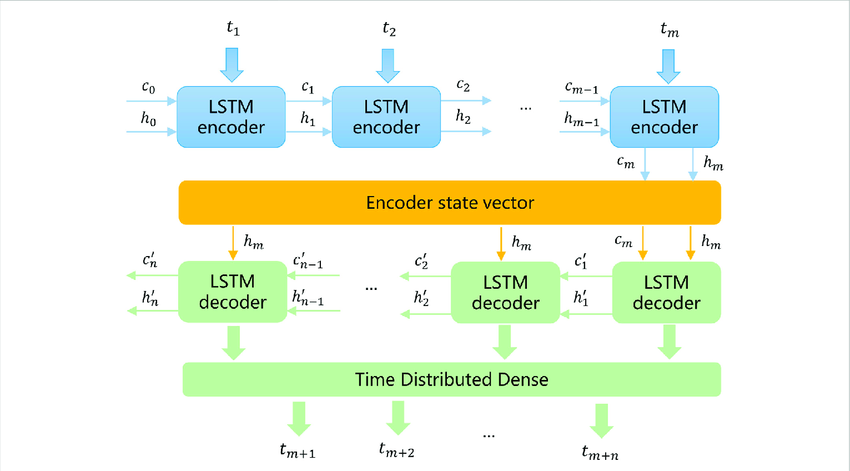

In [7]:
# Create Seq windows
enc_seqs, dec_in_seqs, dec_tgt_seqs = [], [], []
N_total = len(df)

for i in range(N_total - SEQ_LEN - HORIZON + 1):
    # Encoder input (past window)
    enc = X_scaled[i: i + SEQ_LEN]

    # Target values for decoder (future horizon)
    target = y_scaled[i + SEQ_LEN: i + SEQ_LEN + HORIZON].reshape(HORIZON, 1)

    # Decoder input starts with last observed value
    last_obs_ret = y_scaled[i + SEQ_LEN - 1].reshape(1, 1)
    dec_in = np.vstack([last_obs_ret, target[:-1, :]])

    # Store samples
    enc_seqs.append(enc)
    dec_in_seqs.append(dec_in)
    dec_tgt_seqs.append(target)

# Convert lists to NumPy arrays
enc_seqs, dec_in_seqs, dec_tgt_seqs = map(np.array, [enc_seqs, dec_in_seqs, dec_tgt_seqs])
n_features = enc_seqs.shape[2]

# Temporal split
N = enc_seqs.shape[0]
val_size = int(N * VALIDATION_SPLIT)
train_size = N - val_size

X_enc_train, X_dec_in_train, Y_dec_train = enc_seqs[:train_size], dec_in_seqs[:train_size], dec_tgt_seqs[:train_size]
X_enc_val, X_dec_in_val, Y_dec_val = enc_seqs[train_size:], dec_in_seqs[train_size:], dec_tgt_seqs[train_size:]

# Validate window sizes
min_required = SEQ_LEN + HORIZON
if len(df) < min_required:
    raise ValueError(
        f"Not enough data! Need ≥ {min_required} rows but only have {len(df)}. "
        "Reduce SEQ_LEN or HORIZON."
)

print(f"✅ Dataset validated: {len(df)} rows ≥ required {min_required}")

# Save training windows for deployment
np.save(os.path.join(OUT_DIR, "X_enc_train.npy"), X_enc_train)
np.save(os.path.join(OUT_DIR, "X_dec_in_train.npy"), X_dec_in_train)
np.save(os.path.join(OUT_DIR, "Y_dec_train.npy"), Y_dec_train)

np.save(os.path.join(OUT_DIR, "X_enc_val.npy"), X_enc_val)
np.save(os.path.join(OUT_DIR, "X_dec_in_val.npy"), X_dec_in_val)
np.save(os.path.join(OUT_DIR, "Y_dec_val.npy"), Y_dec_val)

print("✅ Windowed datasets saved for deployment in:", OUT_DIR)


✅ Dataset validated: 1256 rows ≥ required 90
✅ Windowed datasets saved for deployment in: model_outputs


### 🔄 Seq2Seq Encoder–Decoder Architecture and Training

This block implements an LSTM-based Sequence-to-Sequence model where:
- The **Encoder** processes historical feature sequences and extracts temporal context.
- The **Decoder** uses this context to predict multiple future time steps iteratively.
- A fully connected layer (`TimeDistributed(Dense)`) produces one output per future timestep.

Training includes callbacks for early stopping and dynamic learning rate adjustment to avoid overfitting and stabilize convergence.

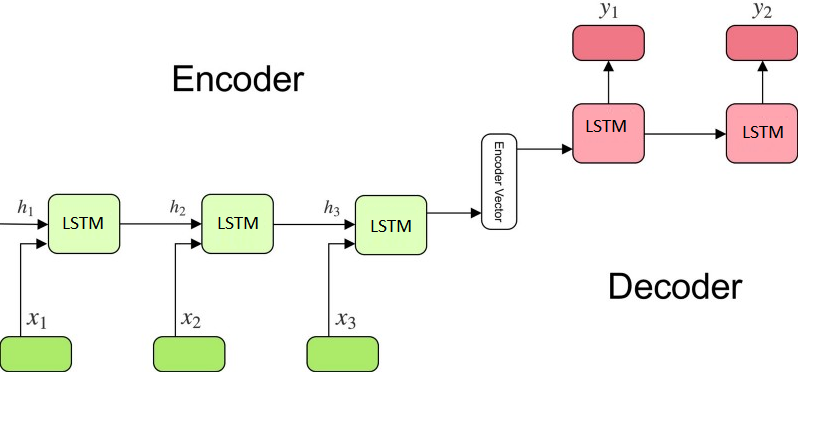
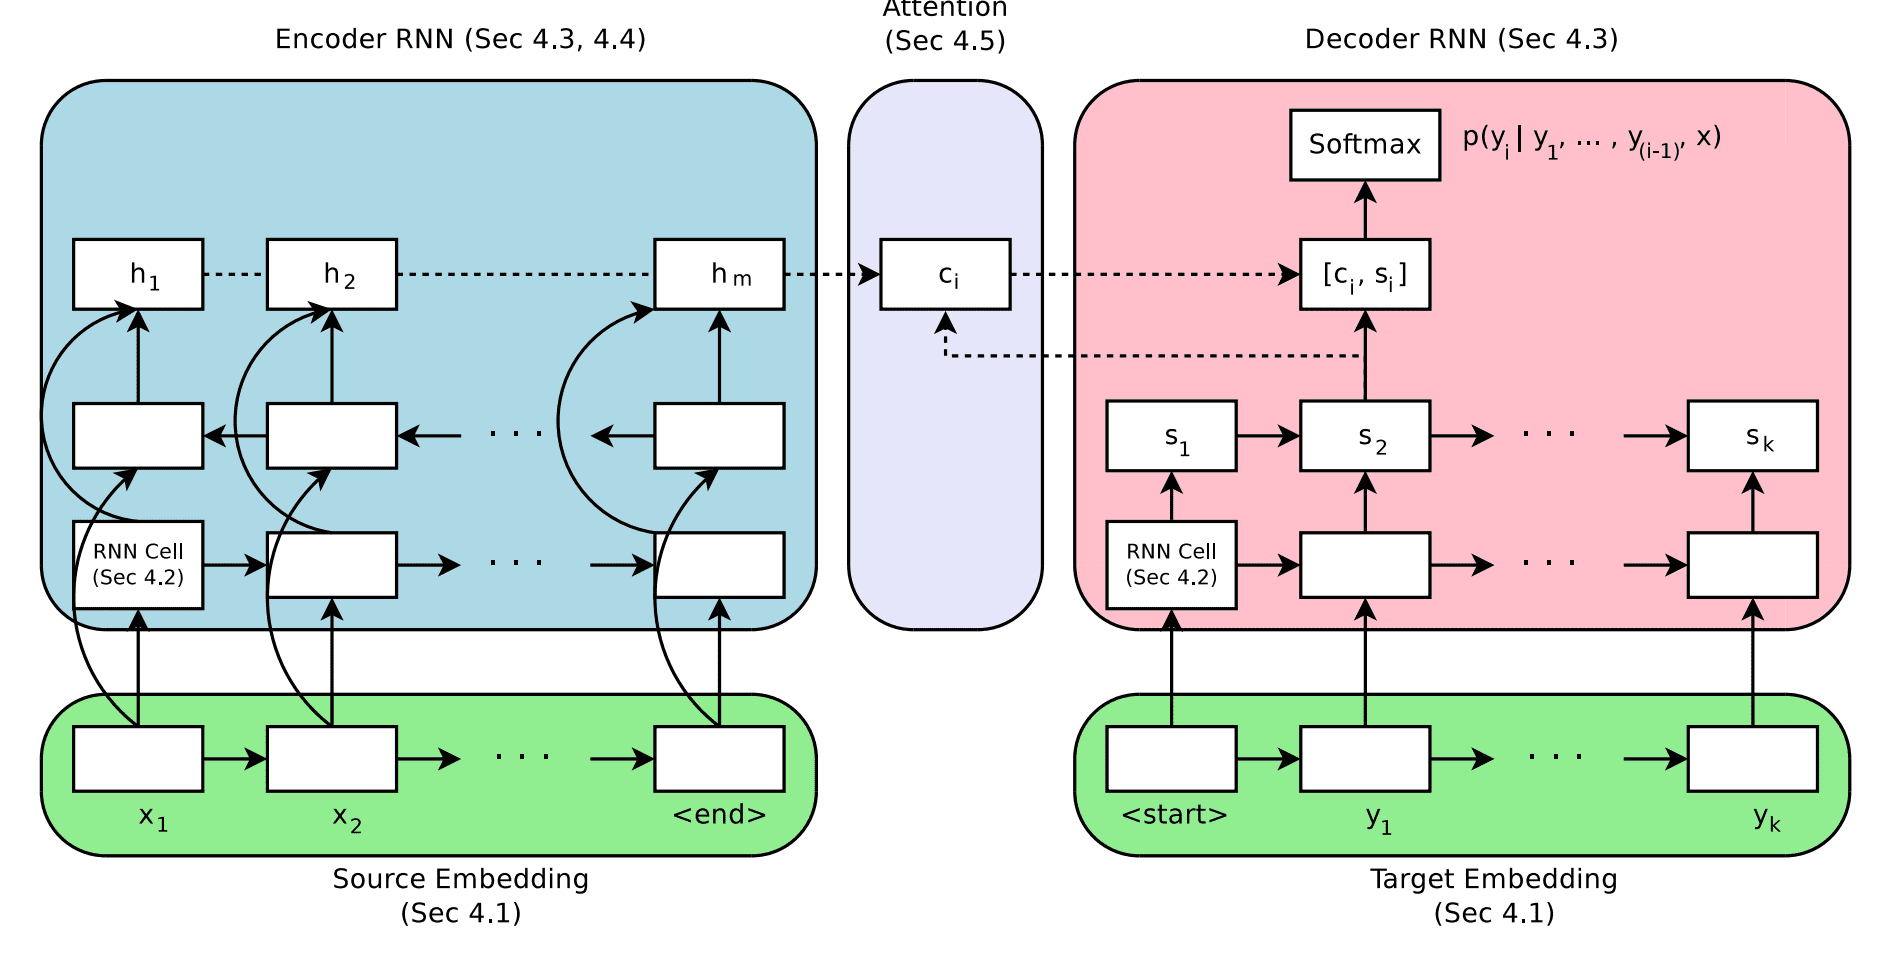


In [8]:
# Seq2Seq Architecture
encoder_inputs = Input(shape=(SEQ_LEN, n_features), name='encoder_inputs')
encoder_lstm = LSTM(LATENT_DIM, return_state=True, name='encoder_lstm')
_, state_h, state_c = encoder_lstm(encoder_inputs)
encoder_states = [state_h, state_c]

decoder_inputs = Input(shape=(HORIZON, 1), name='decoder_inputs')
decoder_lstm = LSTM(LATENT_DIM, return_sequences=True, return_state=True, name='decoder_lstm')
decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)

decoder_dense = TimeDistributed(Dense(1), name='decoder_dense')
decoder_outputs = decoder_dense(decoder_outputs)

# Build and compile model
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='adam', loss='mse')
model.summary()

# Callbacks for stability
es = EarlyStopping(patience=10, restore_best_weights=True)
rlr = ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-6)

# Train
print("\nTraining Seq2Seq...")
history = model.fit(
    [X_enc_train, X_dec_in_train], Y_dec_train,
    validation_data=([X_enc_val, X_dec_in_val], Y_dec_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[es, rlr],
    verbose=2
)

I0000 00:00:1762734589.426378 2589636 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 60, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 30, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 128),     │     68,096 │ encoder_inputs[0… │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 30, 128), │     66,560 │ decoder_inputs[0… │
│                     │ (None, 128),      │            │ encoder_lstm[0][… │
│                     │ (None, 128)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, 30, 1)     │        129 │ decoder_lstm[0][… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 134,785 (526.50 KB)

 Trainable params: 134,785 (526.50 KB)

 Non-trainable params: 0 (0.00 B)


Training Seq2Seq...
Epoch 1/60


2025-11-09 21:29:52.533619: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91500


16/16 - 3s - 191ms/step - loss: 0.9463 - val_loss: 1.2451 - learning_rate: 1.0000e-03
Epoch 2/60
16/16 - 0s - 22ms/step - loss: 0.9379 - val_loss: 1.2512 - learning_rate: 1.0000e-03
Epoch 3/60
16/16 - 0s - 25ms/step - loss: 0.9285 - val_loss: 1.2717 - learning_rate: 1.0000e-03
Epoch 4/60
16/16 - 0s - 23ms/step - loss: 0.9137 - val_loss: 1.2688 - learning_rate: 1.0000e-03
Epoch 5/60
16/16 - 0s - 20ms/step - loss: 0.8981 - val_loss: 1.4143 - learning_rate: 1.0000e-03
Epoch 6/60
16/16 - 0s - 24ms/step - loss: 0.8784 - val_loss: 1.4473 - learning_rate: 1.0000e-03
Epoch 7/60
16/16 - 0s - 28ms/step - loss: 0.8605 - val_loss: 1.5855 - learning_rate: 5.0000e-04
Epoch 8/60
16/16 - 0s - 24ms/step - loss: 0.8421 - val_loss: 1.7932 - learning_rate: 5.0000e-04
Epoch 9/60
16/16 - 0s - 25ms/step - loss: 0.8285 - val_loss: 1.8529 - learning_rate: 5.0000e-04
Epoch 10/60
16/16 - 0s - 26ms/step - loss: 0.8124 - val_loss: 2.0487 - learning_rate: 5.0000e-04
Epoch 11/60
16/16 - 0s - 28ms/step - loss: 0.8016

### 🔄 Seq2Seq Inference Model Setup

This section prepares the inference models for the trained Seq2Seq architecture:

1. **Encoder Inference Model** — encodes input sequences into LSTM states.
2. **Decoder Inference Model** — performs iterative, single-step predictions using the encoded states.
3. **Weights Transfer** — copies trained weights from the training decoder to the inference decoder to ensure predictions are consistent with the trained model.

This setup enables multi-step forecasting by predicting one step at a time and feeding it back iteratively.


In [9]:
# Seq2Seq Inference
# Create encoder model for inference
encoder_model_inf = Model(encoder_inputs, encoder_states)

# Prepare decoder inputs for inference
decoder_state_input_h = Input(shape=(LATENT_DIM,))
decoder_state_input_c = Input(shape=(LATENT_DIM,))
dec_states_inputs = [decoder_state_input_h, decoder_state_input_c]

# Single-step decoder input (for iterative prediction)
decoder_single_input = Input(shape=(1,1))

# Define LSTM layer for decoder in inference mode
decoder_lstm_inf = LSTM(LATENT_DIM, return_sequences=True, return_state=True, name='decoder_lstm_inf')
dec_out_seq, dec_state_h, dec_state_c = decoder_lstm_inf(decoder_single_input, initial_state=dec_states_inputs)

# Output layer for decoder inference
dec_out_single = TimeDistributed(Dense(1), name='decoder_dense_inf')(dec_out_seq)

# Build decoder inference model
decoder_model_inf = Model([decoder_single_input] + dec_states_inputs, [dec_out_single, dec_state_h, dec_state_c])

# Transfer trained weights from training decoder to inference decoder
decoder_lstm_inf.set_weights(decoder_lstm.get_weights())
decoder_model_inf.get_layer('decoder_dense_inf').set_weights(decoder_dense.get_weights())


### 🔮 Seq2Seq Multi-Step Forecast

This section performs multi-step forecasting using the trained Seq2Seq inference models:

1. The last observed sequence of scaled features is encoded to get initial LSTM states.
2. Iteratively, the decoder predicts one step ahead, feeding its output back as input for the next step.
3. Predictions in log-returns are inverse-transformed and converted into price forecasts.
4. Future business dates are generated for the predicted horizon.

The result is a sequence of predicted prices (`seq2seq_preds`) for the next HORIZON steps.


In [10]:
# Seq2Seq Forecast

# Prepare last input sequence for inference
enc_input_last = X_scaled[-SEQ_LEN:].reshape(1, SEQ_LEN, n_features)

# Encode to get initial states
states_value = encoder_model_inf.predict(enc_input_last, verbose=0)
last_obs_ret_scaled = y_scaled[-1].reshape(1,1)

pred_scaled, current_h, current_c = [], states_value[0], states_value[1]

# Iterative multi-step forecasting
for t in range(HORIZON):
    dec_in_t = last_obs_ret_scaled.reshape(1,1,1)
    out_token, h, c = decoder_model_inf.predict([dec_in_t, current_h, current_c], verbose=0)
    next_scaled = float(out_token[0,0,0])
    pred_scaled.append(next_scaled)
    last_obs_ret_scaled = np.array([[next_scaled]])
    current_h, current_c = h, c

pred_scaled = np.array(pred_scaled).reshape(-1,1)

# Inverse scaling to log returns
pred_logrets = scaler_y.inverse_transform(pred_scaled).flatten()

# Convert log returns to prices
S0 = float(df[f'{TICKER}_price'].iloc[-1])
seq2seq_preds = []
price = S0
for lr in pred_logrets:
    price = float(price * np.exp(float(lr)))
    seq2seq_preds.append(price)

# Generate future business dates
future_dates = pd.date_range(start=df.index[-1]+pd.Timedelta(days=1),
                             periods=HORIZON, freq='B')

print("✅ Seq2Seq forecasting completed")


✅ Seq2Seq forecasting completed


### 📊 Multi-Step Forecast Evaluation

This section generates predictions for the validation set using the trained Seq2Seq model, then evaluates the forecasting performance. Metrics are calculated per forecast horizon (step) including RMSE, MAE, MAPE, and MSE, and aggregated into global metrics for an overall assessment of model accuracy. A preview of metrics for the first steps of the horizon is displayed.

In [11]:
# Make predictions for the validation set
preds = model.predict([X_enc_val, X_dec_in_val])

# Function to evaluate multi-step forecasting
def evaluate_window_metrics(y_true, y_pred, scaler_y=None):
    """
    Evaluate multi-step forecasting performance.
    Returns metrics per horizon and aggregated metrics.
    
    Accepted shapes for y_true and y_pred:
        (batch, horizon, 1) or (horizon,)
    """
    
    # Reshape to (batch, horizon)
    y_true = np.squeeze(y_true)
    y_pred = np.squeeze(y_pred)

    # Ensure 2D
    if y_true.ndim == 1:
        y_true = y_true.reshape(1, -1)
        y_pred = y_pred.reshape(1, -1)
        
    # Inverse scaling if scaler provided
    if scaler_y is not None:
        y_true = scaler_y.inverse_transform(y_true)
        y_pred = scaler_y.inverse_transform(y_pred)

    horizon = y_true.shape[1]

    step_metrics = []
    for i in range(horizon):
        mse = mean_squared_error(y_true[:, i], y_pred[:, i])
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        mape = np.mean(np.abs((y_true[:, i] - y_pred[:, i]) / (y_true[:, i] + 1e-8))) * 100
        step_metrics.append([i+1, rmse, mae, mape, mse])

    df_metrics = pd.DataFrame(step_metrics, columns=["Horizon", "RMSE", "MAE", "MAPE", "MSE"])

    # Aggregate global metrics
    global_metrics = {
        "RMSE": np.mean(df_metrics["RMSE"]),
        "MAE":  np.mean(df_metrics["MAE"]),
        "MAPE": np.mean(df_metrics["MAPE"]),
        "MSE":  np.mean(df_metrics["MSE"]),
    }

    return df_metrics, global_metrics

# Evaluate metrics
df_per_step, global_m = evaluate_window_metrics(Y_dec_val, preds, scaler_y)

print("\n📊 Global Forecast Metrics:")
print(global_m)

print("\n🔍 Metrics by Forecast Horizon:")
display(df_per_step.head())


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step

📊 Global Forecast Metrics:
{'RMSE': np.float64(0.042871824345999864), 'MAE': np.float64(0.03133893327693407), 'MAPE': np.float64(123.21623672229421), 'MSE': np.float64(0.001838045762587801)}

🔍 Metrics by Forecast Horizon:


,Horizon,RMSE,MAE,MAPE,MSE
0,1,0.042658,0.031123,129.308565,0.001820
1,2,0.042521,0.030904,127.280465,0.001808
2,3,0.042551,0.031064,134.337133,0.001811
3,4,0.042701,0.031257,137.223008,0.001823
4,5,0.042721,0.031300,141.819651,0.001825


### 🔮 Enhanced Prophet Forecast

This section performs multi-step forecasting using the Prophet model:

1. The historical stock prices are log-transformed to stabilize variance.
2. Prophet is initialized with optimized parameters for financial data:
   - Daily seasonality disabled (not relevant for stocks)
   - Weekly seasonality enabled
   - Yearly seasonality disabled
   - Smoother trend and controlled seasonality
3. The model is fitted and future business dates are generated for the forecast horizon.
4. Predictions are extracted and converted back from log-prices to actual price levels.

The result is a sequence of predicted prices (`prop_preds`) for the next HORIZON steps.


In [12]:
# Enhanced Prophet Forecast
prop_preds = None

if Prophet is not None:
    try:
        # Prepare dataframe for Prophet
        df_prop = df[[f'{TICKER}_price']].copy().reset_index()
        df_prop.columns = ["ds", "y"]
        df_prop["y"] = np.log(df_prop["y"])  # Log-transform for better stationarity
        
        # Optimized parameters
        mprop = Prophet(
            daily_seasonality=False,     # Turn off daily seasonality for stocks
            weekly_seasonality=True,     # Keep weekly seasonality
            yearly_seasonality=False,    # Turn off yearly seasonality
            changepoint_prior_scale=0.05,  # Smaller = smoother trend
            seasonality_prior_scale=10.0,  # Control seasonality strength
            changepoint_range=0.95       # Use 95% of data to detect trend changes
        )
        
        # Fit Prophet model
        mprop.fit(df_prop)
        
        # Create future dataframe for predictions
        fut = mprop.make_future_dataframe(periods=HORIZON, freq="B")
        forecast = mprop.predict(fut)
        
        # Extract predicted log-prices and convert to prices
        prop_preds_log = forecast["yhat"].iloc[-HORIZON:].values
        prop_preds = np.exp(prop_preds_log)
        print("✅ Prophet forecasting completed")
        
    except Exception as e:
        print("Prophet failed:", e)


21:30:00 - cmdstanpy - INFO - Chain [1] start processing
21:30:00 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet forecasting completed


### 🔮 Revised XGBoost Multi-Step Forecast

This section performs multi-step forecasting using XGBoost:

1. Lag features of log returns are created to capture short-term dependencies.
2. Trend features include rolling mean and standard deviation of past returns.
3. The target variable is the next log return.
4. The dataset is split into training and test sets, and an XGBoost regressor is trained.
5. Iterative forecasting for the HORIZON period is performed, where each predicted log return is fed back as input for the next step.
6. Predicted log returns are converted back into actual price forecasts.

The result is a sequence of predicted prices (`xgb_preds`) for the next HORIZON steps.


In [13]:
# XGBoost Forecast
xgb_preds = None

if xgb is not None:
    try:
        df_x = df[[f'{TICKER}_price', f'{TICKER}_lr']].copy()

        # Create lag features for log returns
        LAGS = [1,2,3,5,10]
        for lag in LAGS:
            df_x[f'lag_{lag}'] = df[f'{TICKER}_lr'].shift(lag)
        
        # Trend features: rolling mean and std of returns
        df_x['rm_5'] = df[f'{TICKER}_lr'].rolling(5).mean()
        df_x['std_10'] = df[f'{TICKER}_lr'].rolling(10).std()

        # Target = next log return
        df_x['target'] = df[f'{TICKER}_lr'].shift(-1)
        df_x.dropna(inplace=True)

        feat_cols = [c for c in df_x.columns if c not in ['target', f'{TICKER}_price', f'{TICKER}_lr']]
        Xx, yx = df_x[feat_cols].values, df_x['target'].values

        # Train/test split
        split = int(0.8*len(Xx))
        X_tr, X_te = Xx[:split], Xx[split:]
        y_tr, y_te = yx[:split], yx[split:]

        # Train XGBoost model
        reg = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, tree_method="hist")
        reg.fit(X_tr, y_tr)

        # Iterative HORIZON-step forecast
        tail_rets = df[f'{TICKER}_lr'].values.tolist()
        xgb_preds_scaled = []
        for _ in range(HORIZON):
            vals = {f'lag_{lag}': tail_rets[-lag] for lag in LAGS}
            vals['rm_5'] = np.mean(tail_rets[-5:])
            vals['std_10'] = np.std(tail_rets[-10:])
            feat_vec = np.array([vals[c] for c in feat_cols]).reshape(1,-1)
            pred_lr = float(reg.predict(feat_vec)[0])
            xgb_preds_scaled.append(pred_lr)
            tail_rets.append(pred_lr)

        # Convert log returns to prices
        S0 = float(df[f'{TICKER}_price'].iloc[-1])
        xgb_preds = []
        price = S0
        for lr in xgb_preds_scaled:
            price = price * np.exp(lr)
            xgb_preds.append(price)

        print("✅ XGBoost forecasting completed")
    except Exception as e:
        print("XGBoost failed:", e)


✅ XGBoost forecasting completed


### 🤝 Intelligent Ensemble of Forecasts

This section creates a weighted ensemble of all available forecasting models:

1. **Seq2Seq** predictions receive the highest weight (0.5).
2. **Prophet** predictions are given a medium weight (0.3).
3. **XGBoost** predictions are assigned the lowest weight (0.2).
4. Only models with available predictions are included.
5. Weights are normalized and applied per forecast step to produce a final ensemble forecast.

The result is a combined prediction sequence (`ensemble_preds`) that leverages the strengths of each individual model.


In [14]:
# Intelligent Ensemble
def smart_ensemble(seq2seq_preds, prophet_preds, xgb_preds):
    """Combine models intelligently with dynamic weights"""
    
    available_models = []
    if seq2seq_preds is not None: 
        available_models.append(('seq2seq', seq2seq_preds, 0.5))   # Higher weight
    if prophet_preds is not None: 
        available_models.append(('prophet', prophet_preds, 0.3))   # Medium weight
    if xgb_preds is not None: 
        available_models.append(('xgb', xgb_preds, 0.2))           # Lower weight
    
    if not available_models:
        return seq2seq_preds  # Fallback
    
    # Normalize weights
    total_weight = sum(weight for _, _, weight in available_models)
    ensemble_preds = []
    
    for i in range(HORIZON):
        weighted_sum = 0
        for name, preds, weight in available_models:
            weighted_sum += preds[i] * (weight / total_weight)
        ensemble_preds.append(weighted_sum)
    
    return ensemble_preds

# Calculate ensemble predictions
ensemble_preds = smart_ensemble(seq2seq_preds, prop_preds, xgb_preds)

### 📊 Top 10 Forecasts and Daily Percentage Changes

This section summarizes the first 10 forecasted prices for each model:

1. **Seq2Seq**, **Prophet**, **XGBoost**, and **Ensemble** predictions are displayed side by side.
2. Daily percentage changes are calculated for each model.
3. The first day's percentage change is computed relative to the last observed price.
4. Numeric values are rounded for clarity.
5. The resulting DataFrame is printed and saved as a CSV file (`top10_forecasts_comparison.csv`).

This provides a quick overview of short-term expected movements and model comparisons.


In [15]:
# Top 10 Forecasts DataFrame + Percentages
last_price = df[f'{TICKER}_price'].iloc[-1]
print(f"\nLast observed price of {TICKER}: {last_price:.2f}\n")

n_show = min(10, HORIZON)
df_forecast_compare = pd.DataFrame({
    "Date": future_dates[:n_show],
    "Seq2Seq": seq2seq_preds[:n_show],
    "Prophet": prop_preds[:n_show] if prop_preds is not None else [np.nan]*n_show,
    "XGBoost": xgb_preds[:n_show] if xgb_preds is not None else [np.nan]*n_show,
    "Ensemble": ensemble_preds[:n_show]
})

# Calculate daily percentage change for each model
for col in ["Seq2Seq", "Prophet", "XGBoost","Ensemble"]:
    df_forecast_compare[f"{col} (%)"] = df_forecast_compare[col].pct_change() * 100
    if np.isnan(df_forecast_compare[f"{col} (%)"].iloc[0]):
        df_forecast_compare[f"{col} (%)"].iloc[0] = ((df_forecast_compare[col].iloc[0]/last_price)-1)*100

# Round numeric columns
num_cols = df_forecast_compare.select_dtypes(include=np.number).columns
df_forecast_compare[num_cols] = df_forecast_compare[num_cols].round(2)

print("📈 Top 10 forecasts with daily percentage returns:")
print(df_forecast_compare)

# Save to CSV
df_forecast_compare.to_csv(os.path.join(OUT_DIR, "top10_forecasts_comparison.csv"), index=False)


Last observed price of TSLA: 429.52

📈 Top 10 forecasts with daily percentage returns:
        Date  Seq2Seq  Prophet  XGBoost  Ensemble  Seq2Seq (%)  Prophet (%)  \
0 2025-11-10   428.86   462.14   428.69    438.81        -0.15         7.59   
1 2025-11-11   427.32   462.42   426.88    437.76        -0.36         0.06   
2 2025-11-12   425.03   464.44   424.87    436.82        -0.54         0.44   
3 2025-11-13   422.22   463.17   420.08    434.08        -0.66        -0.27   
4 2025-11-14   419.10   466.10   420.69    433.52        -0.74         0.63   
5 2025-11-17   415.79   472.53   424.12    434.48        -0.79         1.38   
6 2025-11-18   412.41   472.82   423.58    432.77        -0.81         0.06   
7 2025-11-19   409.05   474.88   419.77    430.94        -0.81         0.44   
8 2025-11-20   405.78   473.58   419.04    428.77        -0.80        -0.27   
9 2025-11-21   402.64   476.58   421.95    428.68        -0.77         0.63   

   XGBoost (%)  Ensemble (%)  
0        -0

### 📈 Model Comparison Plot

This section visualizes the historical prices of the target stock and the forecasts from different models:

1. Historical prices are plotted for the last 200 days.
2. Future predictions from **Seq2Seq**, **Prophet**, **XGBoost**, and **Ensemble** are plotted with distinct markers and colors.
3. The plot helps visually compare the predicted trajectories of each model against historical trends.


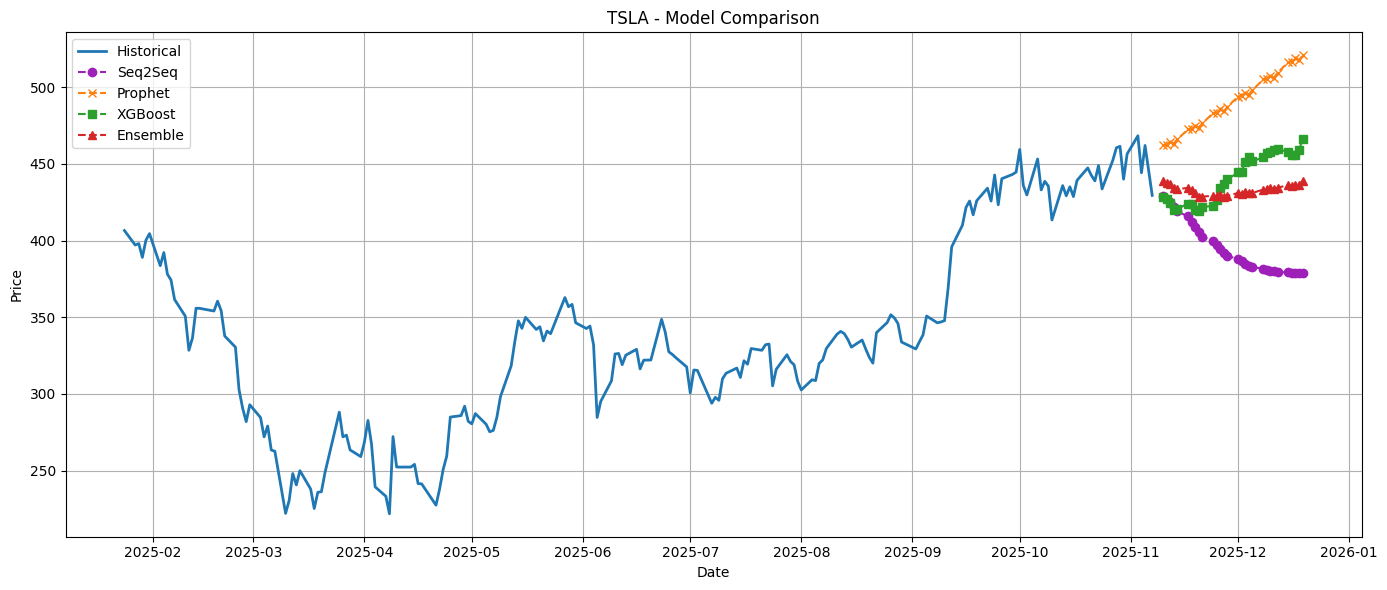

In [16]:
# Comparative Plot I
plt.figure(figsize=(14,6))

# Historical prices
plt.plot(df.index[-200:], df[f'{TICKER}_price'].iloc[-200:], label="Historical", linewidth=2)

# Future forecasts
colors = ["#9f1fb9", '#ff7f0e', '#2ca02c', '#d62728']  # Consistent colors
plt.plot(future_dates, seq2seq_preds, marker='o', linestyle='--', color=colors[0], label="Seq2Seq")
if prop_preds is not None:
    plt.plot(future_dates, prop_preds, marker='x', linestyle='--', color=colors[1], label="Prophet")
if xgb_preds is not None:
    plt.plot(future_dates, xgb_preds, marker='s', linestyle='--', color=colors[2], label="XGBoost")
plt.plot(future_dates, ensemble_preds, marker='^', linestyle='--', color=colors[3], label="Ensemble")

plt.title(f"{TICKER} - Model Comparison")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### 📊 Model Comparison Plot II

This plot combines:

1. The last 3 observed stock prices, highlighted with red markers and labels.
2. Future forecasts from **Seq2Seq**, **Prophet**, **XGBoost**, and **Ensemble**.
3. Distinct colors and markers for each model for clarity.
4. Provides a visual bridge between recent observed prices and projected future prices, helping assess model trends relative to recent market behavior.


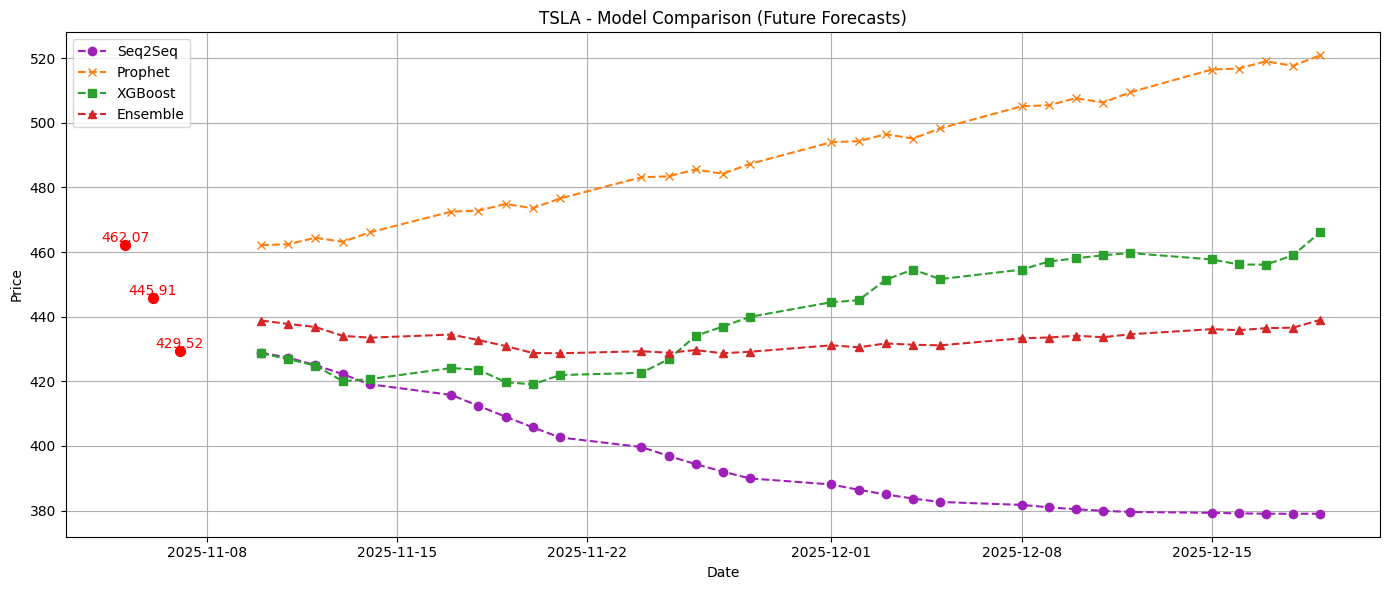

In [17]:
# Comparative Plot II
plt.figure(figsize=(14,6))

# Last 3 observed prices
last_prices = df[f'{TICKER}_price'].iloc[-3:]
last_dates = df.index[-3:]
plt.scatter(last_dates, last_prices, color='red', s=50)
for d, p in zip(last_dates, last_prices):
    plt.text(d, p, f"{p:.2f}", fontsize=10, ha='center', va='bottom', color="red")

# Future forecast plots
colors = ["#9f1fb9", '#ff7f0e', '#2ca02c', '#d62728']  # Consistent colors
plt.plot(future_dates, seq2seq_preds, marker='o', linestyle='--', color=colors[0], label="Seq2Seq")
if prop_preds is not None:
    plt.plot(future_dates, prop_preds, marker='x', linestyle='--', color=colors[1], label="Prophet")
if xgb_preds is not None:
    plt.plot(future_dates, xgb_preds, marker='s', linestyle='--', color=colors[2], label="XGBoost")
plt.plot(future_dates, ensemble_preds, marker='^', linestyle='--', color=colors[3], label="Ensemble")

plt.title(f"{TICKER} - Model Comparison (Future Forecasts)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### 📌 Final Recommendation & Market Signal

This section aggregates the final predictions from all active forecasting models and
computes a **consensus market signal**. The logic evaluates:

- 📈 Expected return over the next 30 days
- 🎯 Average target price across models
- 📊 Consensus risk measured by prediction dispersion (standard deviation)

Based on these metrics, a **Buy / Sell / Neutral** recommendation is generated.  
Final predictions are saved in `final_forecasts.csv` for use in BI dashboards.


In [18]:
# FINAL RECOMMENDATION ----------------
print(f"\n🎯 FINAL RECOMMENDATION FOR {TICKER}")
print("="*80)

# Gather available predictions
model_preds = {
    "Seq2Seq": seq2seq_preds,
    "Prophet": prop_preds,
    "XGBoost": xgb_preds,
    "Ensemble": ensemble_preds
}

# Filter out missing model predictions
valid_models = {name: preds for name, preds in model_preds.items() if preds is not None}

# Last real observed price
last_price = df[f'{TICKER}_price'].iloc[-1]

# Final predicted price per model
final_predictions = {name: preds[-1] for name, preds in valid_models.items()}
avg_final_price = np.mean(list(final_predictions.values()))

# Consensus expected return
consensus_return = ((avg_final_price / last_price) - 1) * 100

# Standard deviation of predictions (consensus risk)
consensus_risk = np.std(list(final_predictions.values()))

# Recommendation logic
if consensus_return > 8:
    recommendation = "STRONG BUY 🚀"
elif consensus_return > 4:
    recommendation = "BUY 📈"
elif consensus_return > 1:
    recommendation = "MODERATE BUY 🔼"
elif consensus_return < -8:
    recommendation = "STRONG SELL ⚠️📉"
elif consensus_return < -4:
    recommendation = "SELL 📉"
elif consensus_return < -1:
    recommendation = "MODERATE SELL 🔽"
else:
    recommendation = "NEUTRAL ↔️"

# Output results
print(f"📌 Models considered: {', '.join(valid_models.keys())}")
print(f"💰 Last observed price: {last_price:.2f}")
print(f"🎯 Average target price (30 days): {avg_final_price:.2f}")
print(f"📈 Expected average return: {consensus_return:.2f}%")
print(f"📊 Consensus risk (std): {consensus_risk:.2f}")
print(f"\n✅ Final Recommendation: **{recommendation}**")

print("\n⚠️ DISCLAIMER:")
print("These projections are statistical estimates and do not constitute financial advice.")
print("Always consider macroeconomic factors, fundamentals, and risk management.")

# ---------------- 19) SAVE FINAL RESULTS ----------------
final_results = pd.DataFrame({
    'Date': future_dates,
    **{name: preds for name, preds in valid_models.items()}
})

final_results.to_csv(os.path.join(OUT_DIR, "final_forecasts.csv"), index=False)
print(f"\n💾 Complete results saved to: final_forecasts.csv")
print(f"\n✅ FULL ANALYSIS SUCCESSFULLY COMPLETED ✅")



🎯 FINAL RECOMMENDATION FOR TSLA
📌 Models considered: Seq2Seq, Prophet, XGBoost, Ensemble
💰 Last observed price: 429.52
🎯 Average target price (30 days): 451.27
📈 Expected average return: 5.06%
📊 Consensus risk (std): 51.08

✅ Final Recommendation: **BUY 📈**

⚠️ DISCLAIMER:
These projections are statistical estimates and do not constitute financial advice.
Always consider macroeconomic factors, fundamentals, and risk management.

💾 Complete results saved to: final_forecasts.csv

✅ FULL ANALYSIS SUCCESSFULLY COMPLETED ✅


### 📊 Comparative Evaluation of Forecasting Models

This section evaluates the forecasting models by comparing prediction accuracy and error behavior across multiple metrics, including RMSE, MAE, MAPE and Directional Accuracy. It also automatically generates visual diagnostics such as:

- Bar chart comparing metrics across models
- Boxplot visualizing error distributions
- Heatmap showing correlation between model errors

The analysis includes Seq2Seq, Prophet, XGBoost, Ensemble, and a Naive baseline model.



📊 Model metrics comparison (last HORIZON days):
                   Seq2Seq  Prophet  XGBoost  Ensemble  Naive
RMSE                 52.75    50.79    14.92     14.78  12.18
MAE                  47.44    47.55    11.70     11.80   9.84
MAPE (%)             10.62    10.77     2.65      2.62   2.22
Direction Acc (%)    44.83    65.52    51.72     75.86   0.00


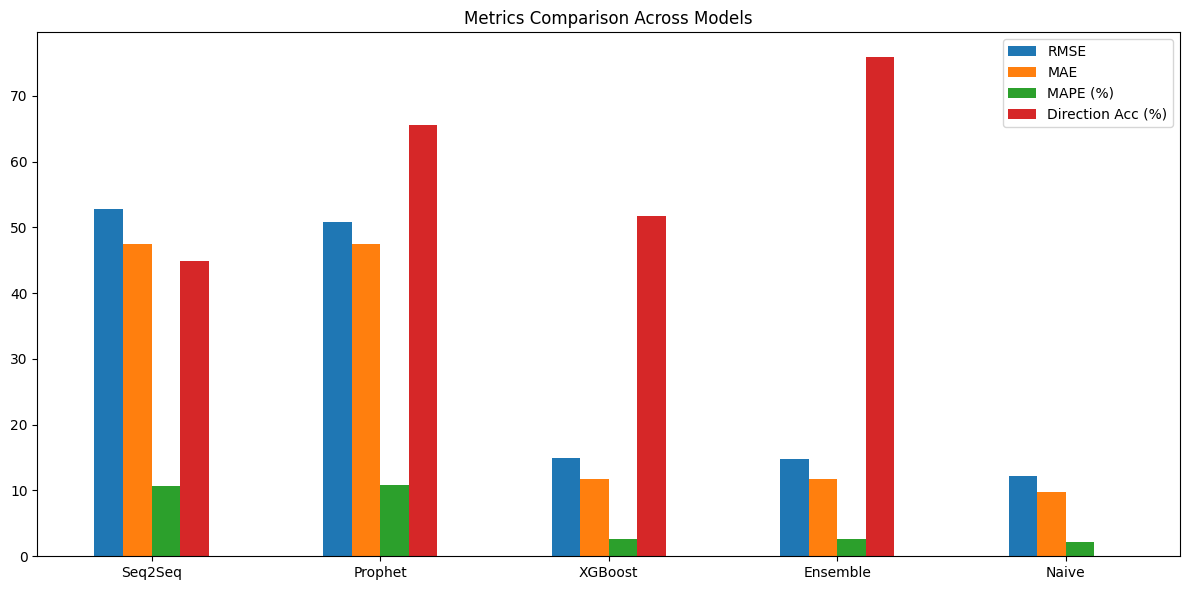

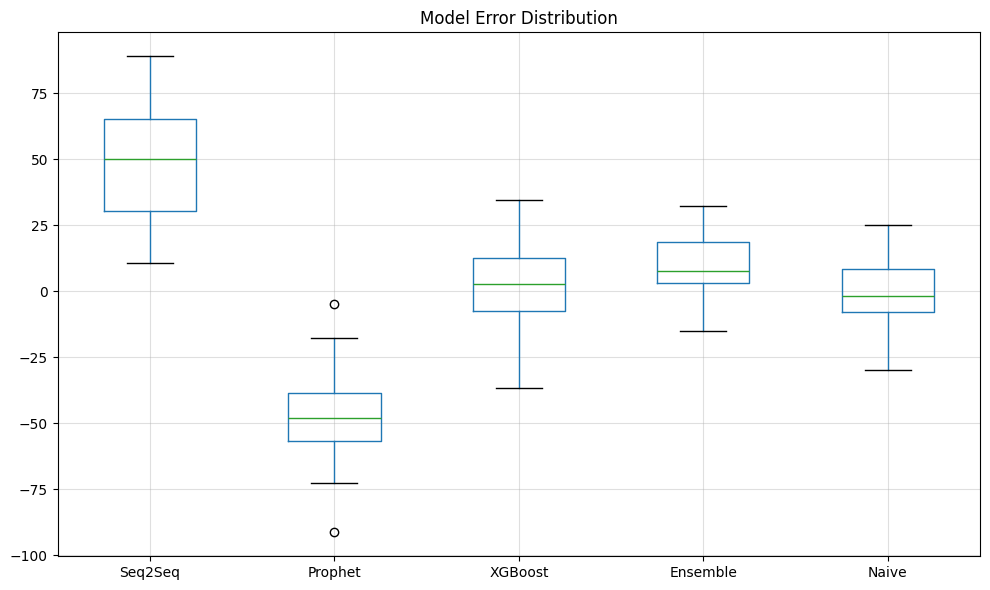

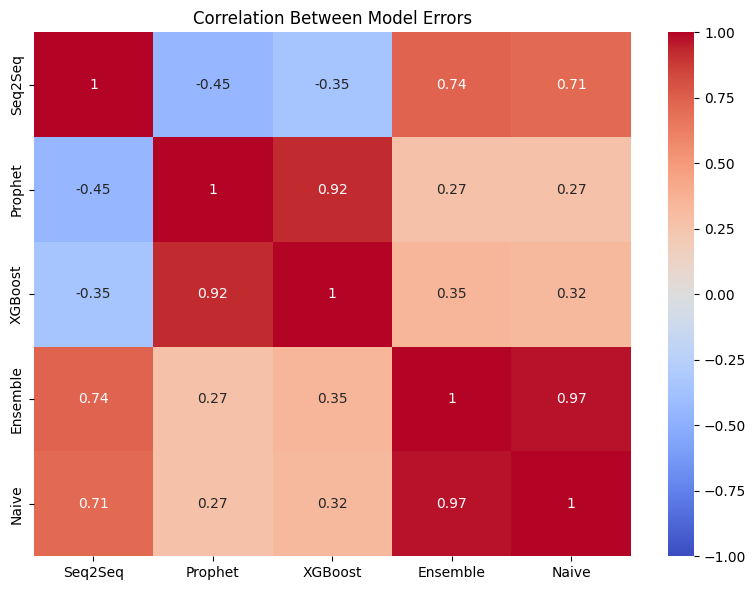

In [19]:
# Comparative Metrics + Charts ----------------
def calc_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true==0, 1e-8, y_true))) * 100
    
    true_dir = np.sign(np.diff(y_true))
    pred_dir = np.sign(np.diff(y_pred))
    direction_acc = (true_dir == pred_dir).mean() * 100
    
    return rmse, mae, mape, direction_acc

y_true_future = df[f'{TICKER}_price'].iloc[-HORIZON:].values
metrics = {}

# Predictive Models
metrics['Seq2Seq'] = calc_metrics(y_true_future, np.array(seq2seq_preds[:HORIZON]))
if prop_preds is not None:
    metrics['Prophet'] = calc_metrics(y_true_future, np.array(prop_preds[:HORIZON]))
if xgb_preds is not None:
    metrics['XGBoost'] = calc_metrics(y_true_future, np.array(xgb_preds[:HORIZON]))
metrics['Ensemble'] = calc_metrics(y_true_future, np.array(ensemble_preds[:HORIZON]))

# Naive Baseline (uses last available price)
naive_preds = np.repeat(y_true_future[0], HORIZON)
metrics['Naive'] = calc_metrics(y_true_future, naive_preds)

df_metrics = pd.DataFrame(metrics, index=['RMSE','MAE','MAPE (%)','Direction Acc (%)']).round(2)
print("\n📊 Model metrics comparison (last HORIZON days):")
print(df_metrics)

# Automatic Additional Charts

# Metrics comparison chart
df_metrics.T[['RMSE','MAE','MAPE (%)','Direction Acc (%)']].plot(kind='bar', figsize=(12,6))
plt.title("Metrics Comparison Across Models")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,"metrics_comparison_bar.png"))
plt.show()

# Error distribution (Boxplot)
errors = pd.DataFrame({
    'Seq2Seq': y_true_future - seq2seq_preds[:HORIZON],
    'Prophet': y_true_future - prop_preds[:HORIZON] if prop_preds is not None else np.nan,
    'XGBoost': y_true_future - xgb_preds[:HORIZON] if xgb_preds is not None else np.nan,
    'Ensemble': y_true_future - ensemble_preds[:HORIZON],
    'Naive': y_true_future - naive_preds
})
errors.boxplot(figsize=(10,6))
plt.title("Model Error Distribution")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,"error_boxplot.png"))
plt.show()

# Error correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(errors.corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm")
plt.title("Correlation Between Model Errors")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,"error_heatmap.png"))
plt.show()

### 🎲 Comparative Monte Carlo Simulation for Risk Assessment
This section performs a Monte Carlo simulation using the predicted log-returns from Seq2Seq, Prophet, and XGBoost models. It generates 500 stochastic price paths per model to estimate potential future price uncertainty.

The output provides:

- Mean forecasted price trajectory
- 5th and 95th percentile confidence bounds (risk intervals)
- Forecast comparison plot across models
- Risk assessment based on confidence range width
- Optimism vs. conservatism insight based on final price expectation

This step helps evaluate volatility, downside risk, and the credibility of each model’s projections.



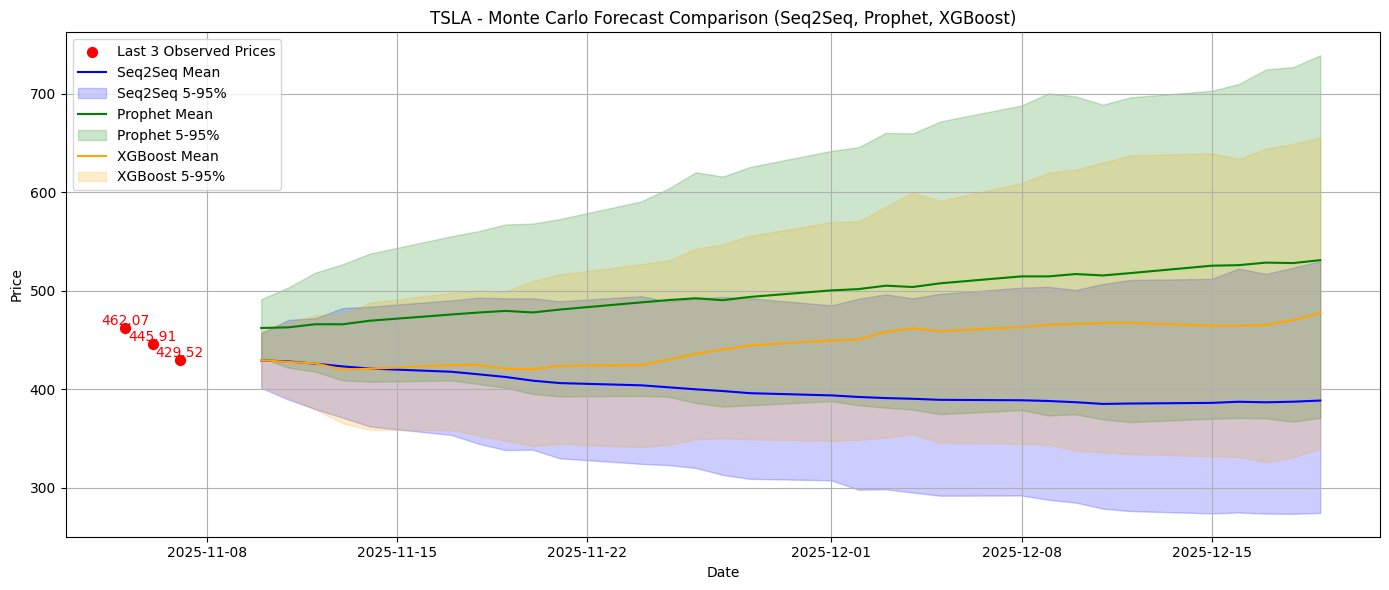


🔍 RISK ANALYSIS - CONFIDENCE INTERVALS & RISK METRICS
Seq2Seq - Avg 5-95% Range Width: $179.93
Prophet - Avg 5-95% Range Width: $238.77
XGBoost - Avg 5-95% Range Width: $212.21

📉 Value at Risk (VaR 95%) - Worst 5% expected return:
 - Seq2Seq: -36.13%
 - Prophet: -13.68%
 - XGBoost: -20.96%

⚠️ Conditional VaR (CVaR 95%) - Avg of worst 5% cases:
 - Seq2Seq: -42.49%
 - Prophet: -20.46%
 - XGBoost: -28.99%

📈 Sharpe Ratio (Annualized):
 - Seq2Seq: -10.44
 - Prophet: 12.29
 - XGBoost: 5.34

📉 Seq2Seq is more conservative than Prophet at the end of the forecast
📉 Seq2Seq is more conservative than XGBoost at the end of the forecast


In [20]:
# Comparative Monte Carlo Simulation (Seq2Seq, Prophet, XGBoost)
np.random.seed(42)

N_SIM = 500        # number of simulated paths
HORIZON_MC = HORIZON
S0 = float(df[f'{TICKER}_price'].iloc[-1])

def monte_carlo_paths(pred_logrets, S0, N_SIM):
    """
    Generates N Monte Carlo simulation paths using forecasted log-returns.
    Daily volatility is estimated from the last 10 days of observed returns.
    """
    paths = np.zeros((HORIZON_MC, N_SIM))
    vol_daily = df[f'{TICKER}_lr'].rolling(10).std().iloc[-1]

    for i in range(N_SIM):
        price = S0
        for t in range(HORIZON_MC):
            lr = pred_logrets[t] + np.random.normal(0, vol_daily)
            price *= np.exp(lr)
            paths[t, i] = price

    return paths


def logrets_from_prices(prices, S0):
    """Converts price forecasts to log-returns ensuring HORIZON size."""
    lr = np.zeros(HORIZON)
    for t in range(HORIZON):
        lr[t] = np.log(prices[t] / (S0 if t == 0 else prices[t - 1]))
    return lr

# Generate log-returns for each model
seq_logrets = pred_logrets  # already computed for Seq2Seq
prop_logrets = logrets_from_prices(prop_preds, S0) if prop_preds is not None else np.zeros(HORIZON)
xgb_logrets = logrets_from_prices(xgb_preds, S0) if xgb_preds is not None else np.zeros(HORIZON)

# Run Monte Carlo simulations
mc_seq2seq = monte_carlo_paths(seq_logrets, S0, N_SIM)
mc_prophet = monte_carlo_paths(prop_logrets, S0, N_SIM)
mc_xgb = monte_carlo_paths(xgb_logrets, S0, N_SIM)

# Compute stats: mean and confidence intervals
def mc_stats(mc_paths):
    """Computes mean and confidence bounds across simulations."""
    return (
        mc_paths.mean(axis=1),
        np.percentile(mc_paths, 5, axis=1),
        np.percentile(mc_paths, 95, axis=1)
    )

# Extract mean + 5–95% uncertainty interval
seq_mean, seq_5, seq_95 = mc_stats(mc_seq2seq)
prop_mean, prop_5, prop_95 = mc_stats(mc_prophet)
xgb_mean, xgb_5, xgb_95 = mc_stats(mc_xgb)

# Risk Metrics (VaR, CVaR & Sharpe Ratio)
def compute_risk_metrics(paths, S0):
    """
    Computes:
    - VaR 95%: Worst expected loss* over 5% tail
    - CVaR 95%: Average loss in the worst 5% cases
    - Sharpe Ratio: Annualized risk-adjusted return
    """
    final_prices = paths[-1]
    returns = (final_prices / S0) - 1

    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()

    risk_free_rate = 0.03  # Optional: adjust later
    sharpe = ((returns.mean() - risk_free_rate) /
              returns.std()) * np.sqrt(252)

    return var_95, cvar_95, sharpe

seq_var, seq_cvar, seq_sharpe = compute_risk_metrics(mc_seq2seq, S0)
prop_var, prop_cvar, prop_sharpe = compute_risk_metrics(mc_prophet, S0)
xgb_var, xgb_cvar, xgb_sharpe = compute_risk_metrics(mc_xgb, S0)

# Comparative DataFrame
df_mc_compare = pd.DataFrame({
    "Date": future_dates,
    "Seq2Seq_Mean": seq_mean,
    "Seq2Seq_5th": seq_5,
    "Seq2Seq_95th": seq_95,
    "Prophet_Mean": prop_mean,
    "Prophet_5th": prop_5,
    "Prophet_95th": prop_95,
    "XGBoost_Mean": xgb_mean,
    "XGBoost_5th": xgb_5,
    "XGBoost_95th": xgb_95
})

# Plot Monte Carlo Results
plt.figure(figsize=(14,6))

# Plot latest observed prices
last_prices = df[f'{TICKER}_price'].iloc[-3:]
last_dates = df.index[-3:]
plt.scatter(last_dates, last_prices, color='red', s=50, label="Last 3 Observed Prices")
for d, p in zip(last_dates, last_prices):
    plt.text(d, p, f"{p:.2f}", fontsize=10, ha='center', va='bottom', color='red')

# Seq2Seq curves & confidence band
plt.plot(future_dates, seq_mean, color='blue', linestyle='-', label="Seq2Seq Mean")
plt.fill_between(future_dates, seq_5, seq_95, color='blue', alpha=0.2, label="Seq2Seq 5-95%")

# Prophet curves & confidence band
if prop_preds is not None:
    plt.plot(future_dates, prop_mean, color='green', linestyle='-', label="Prophet Mean")
    plt.fill_between(future_dates, prop_5, prop_95, color='green', alpha=0.2, label="Prophet 5-95%")

# XGBoost curves & confidence band
if xgb_preds is not None:
    plt.plot(future_dates, xgb_mean, color='orange', linestyle='-', label="XGBoost Mean")
    plt.fill_between(future_dates, xgb_5, xgb_95, color='orange', alpha=0.2, label="XGBoost 5-95%")

plt.title(f"{TICKER} - Monte Carlo Forecast Comparison (Seq2Seq, Prophet, XGBoost)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Compute confidence range width
seq_confidence_range = seq_95 - seq_5
prop_confidence_range = prop_95 - prop_5
xgb_confidence_range = xgb_95 - xgb_5

# Risk Analysis Output
print("\n🔍 RISK ANALYSIS - CONFIDENCE INTERVALS & RISK METRICS")
print("=" * 60)

print(f"Seq2Seq - Avg 5-95% Range Width: ${np.mean(seq_95 - seq_5):.2f}")
print(f"Prophet - Avg 5-95% Range Width: ${np.mean(prop_95 - prop_5):.2f}")
print(f"XGBoost - Avg 5-95% Range Width: ${np.mean(xgb_95 - xgb_5):.2f}\n")

print(f"📉 Value at Risk (VaR 95%) - Worst 5% expected return:")
print(f" - Seq2Seq: {seq_var:.2%}")
print(f" - Prophet: {prop_var:.2%}")
print(f" - XGBoost: {xgb_var:.2%}\n")

print(f"⚠️ Conditional VaR (CVaR 95%) - Avg of worst 5% cases:")
print(f" - Seq2Seq: {seq_cvar:.2%}")
print(f" - Prophet: {prop_cvar:.2%}")
print(f" - XGBoost: {xgb_cvar:.2%}\n")

print(f"📈 Sharpe Ratio (Annualized):")
print(f" - Seq2Seq: {seq_sharpe:.2f}")
print(f" - Prophet: {prop_sharpe:.2f}")
print(f" - XGBoost: {xgb_sharpe:.2f}\n")

# Compare optimism/conservatism
if seq_mean[-1] > prop_mean[-1]:
    print(f"📈 Seq2Seq is more optimistic than Prophet at the end of the forecast")
else:
    print(f"📉 Seq2Seq is more conservative than Prophet at the end of the forecast")

if seq_mean[-1] > xgb_mean[-1]:
    print(f"📈 Seq2Seq is more optimistic than XGBoost at the end of the forecast")
else:
    print(f"📉 Seq2Seq is more conservative than XGBoost at the end of the forecast")

## 🔄 Monte Carlo Simulation for Risk Comparison

This code performs a Monte Carlo simulation using forecasted log-returns from two models (Seq2Seq and Ensemble) to generate multiple future price paths. It then calculates mean projected trajectories and confidence intervals (5th–95th percentiles) to quantify uncertainty and evaluate comparative risk between models.


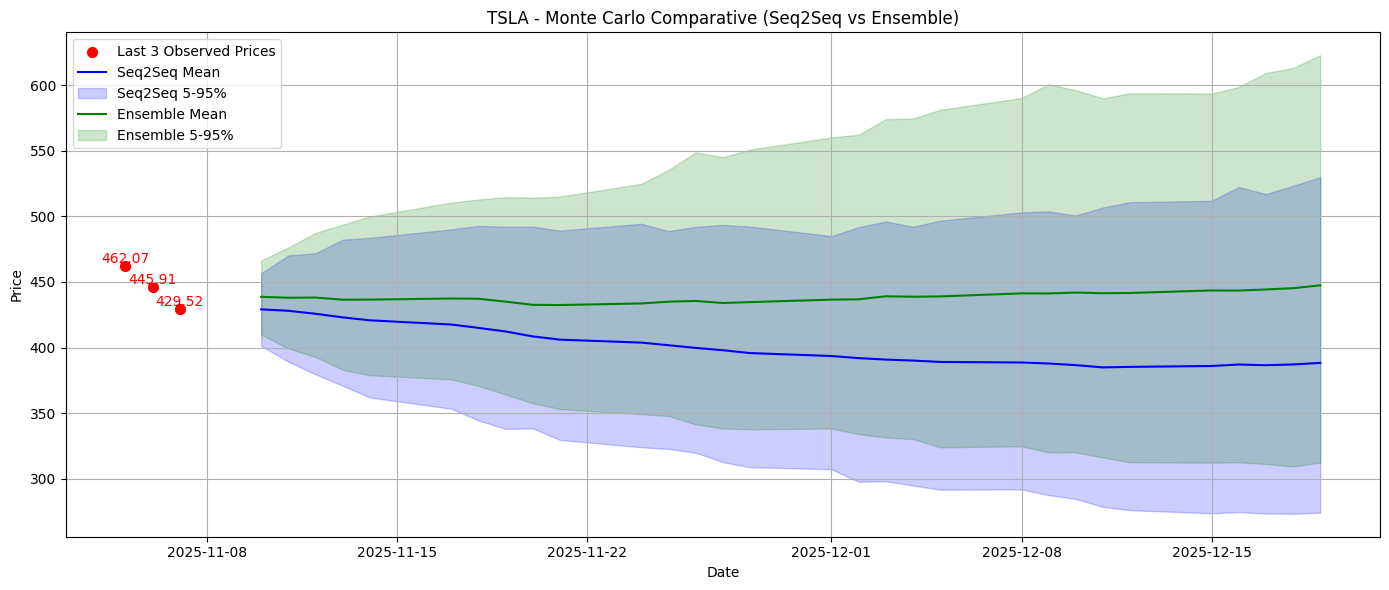


🔍 RISK ANALYSIS - CONFIDENCE INTERVALS & RISK METRICS
Seq2Seq - Avg Confidence Range (5–95%): $179.93
Ensemble - Avg Confidence Range (5–95%): $208.15

📉 Value at Risk (VaR 95%) - Worst 5% expected return:
 - Seq2Seq: -36.13%
 - Ensemble: -27.25%

⚠️ Conditional VaR (CVaR 95%) - Avg of worst 5% cases:
 - Seq2Seq: -42.49%
 - Ensemble: -32.96%

📈 Sharpe Ratio (Annualized):
 - Seq2Seq: -10.44
 - Ensemble: 0.83

✅ Ensemble is more optimistic at the end of the horizon.


In [21]:
# Monte Carlo Comparative (Seq2Seq, Ensemble)
np.random.seed(42)

N_SIM = 500        # Number of simulated price paths
HORIZON_MC = HORIZON
S0 = float(df[f'{TICKER}_price'].iloc[-1])  # Last observed price


def monte_carlo_paths(pred_logrets, S0, N_SIM):
    """
    Generates N Monte Carlo simulation paths using forecasted log-returns.
    Daily volatility is estimated from the last 10 days of observed returns.
    """
    paths = np.zeros((HORIZON_MC, N_SIM))
    vol_daily = df[f'{TICKER}_lr'].rolling(10).std().iloc[-1]

    for i in range(N_SIM):
        price = S0
        for t in range(HORIZON_MC):
            lr = pred_logrets[t] + np.random.normal(0, vol_daily)
            price *= np.exp(lr)
            paths[t, i] = price

    return paths

def logrets_from_prices(prices, S0):
    """Converts price forecasts to log-returns ensuring HORIZON size."""
    lr = np.zeros(HORIZON)
    for t in range(HORIZON):
        lr[t] = np.log(prices[t] / (S0 if t == 0 else prices[t - 1]))
    return lr

# Generate log-returns for each model
seq_logrets = pred_logrets
ens_logrets = logrets_from_prices(ensemble_preds, S0)


# Run Monte Carlo simulations
mc_seq2seq = monte_carlo_paths(seq_logrets, S0, N_SIM)
mc_ens = monte_carlo_paths(ens_logrets, S0, N_SIM)


def mc_stats(mc_paths):
    """Computes mean and confidence bounds across simulations."""
    return (
        mc_paths.mean(axis=1),
        np.percentile(mc_paths, 5, axis=1),
        np.percentile(mc_paths, 95, axis=1)
    )

# Extract mean + 5–95% uncertainty interval
seq_mean, seq_5, seq_95 = mc_stats(mc_seq2seq)
ens_mean, ens_5, ens_95 = mc_stats(mc_ens)

# Risk Metrics (VaR, CVaR & Sharpe Ratio)
def compute_risk_metrics(paths, S0):
    """
    Computes:
    - VaR 95%: Worst expected loss* over 5% tail
    - CVaR 95%: Average loss in the worst 5% cases
    - Sharpe Ratio: Annualized risk-adjusted return
    """
    final_prices = paths[-1]
    returns = (final_prices / S0) - 1

    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()

    risk_free_rate = 0.03  # Optional: adjust later
    sharpe = ((returns.mean() - risk_free_rate) /
              returns.std()) * np.sqrt(252)

    return var_95, cvar_95, sharpe

seq_var, seq_cvar, seq_sharpe = compute_risk_metrics(mc_seq2seq, S0)
ens_var, ens_cvar, ens_sharpe = compute_risk_metrics(mc_ens, S0)


# Comparative DataFrame
df_mc_compare = pd.DataFrame({
    "Date": future_dates,
    "Seq2Seq_Mean": seq_mean,
    "Seq2Seq_5th": seq_5,
    "Seq2Seq_95th": seq_95,
    "Ensemble_Mean": ens_mean,
    "Ensemble_5th": ens_5,
    "Ensemble_95th": ens_95
})

# Monte Carlo Plot
plt.figure(figsize=(14,6))

# Plot latest observed prices
last_prices = df[f'{TICKER}_price'].iloc[-3:]
last_dates = df.index[-3:]
plt.scatter(last_dates, last_prices, color='red', s=50, label="Last 3 Observed Prices")
for d, p in zip(last_dates, last_prices):
    plt.text(d, p, f"{p:.2f}", fontsize=10, ha='center', va='bottom', color='red')

# Seq2Seq curves & confidence band
plt.plot(future_dates, seq_mean, color='blue', linestyle='-', label="Seq2Seq Mean")
plt.fill_between(future_dates, seq_5, seq_95, color='blue', alpha=0.2, label="Seq2Seq 5-95%")

# Ensemble curves & confidence band
plt.plot(future_dates, ens_mean, color='green', linestyle='-', label="Ensemble Mean")
plt.fill_between(future_dates, ens_5, ens_95, color='green', alpha=0.2, label="Ensemble 5-95%")

plt.title(f"{TICKER} - Monte Carlo Comparative (Seq2Seq vs Ensemble)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Interval width (uncertainty)
seq_confidence_range = seq_95 - seq_5
ens_confidence_range = ens_95 - ens_5

# ---------------- Risk Analysis Output ----------------
print("\n🔍 RISK ANALYSIS - CONFIDENCE INTERVALS & RISK METRICS")
print("=" * 60)

print(f"Seq2Seq - Avg Confidence Range (5–95%): ${np.mean(seq_95 - seq_5):.2f}")
print(f"Ensemble - Avg Confidence Range (5–95%): ${np.mean(ens_95 - ens_5):.2f}\n")

print(f"📉 Value at Risk (VaR 95%) - Worst 5% expected return:")
print(f" - Seq2Seq: {seq_var:.2%}")
print(f" - Ensemble: {ens_var:.2%}\n")

print(f"⚠️ Conditional VaR (CVaR 95%) - Avg of worst 5% cases:")
print(f" - Seq2Seq: {seq_cvar:.2%}")
print(f" - Ensemble: {ens_cvar:.2%}\n")

print(f"📈 Sharpe Ratio (Annualized):")
print(f" - Seq2Seq: {seq_sharpe:.2f}")
print(f" - Ensemble: {ens_sharpe:.2f}\n")

if seq_mean[-1] > ens_mean[-1]:
    print("✅ Seq2Seq is more optimistic at the end of the horizon.")
else:
    print("✅ Ensemble is more optimistic at the end of the horizon.")

## Part II - Volatility

## 📌 Volatility Forecasting Using Seq2Seq Model


This section forecasts short-term volatility using a Seq2Seq neural network. Historical volatility is calculated from the rolling standard deviation of log-returns. The model uses the same encoded price features but predicts volatility over the forecast horizon. The data is scaled and formatted into encoder/decoder inputs for training and evaluation.


In [22]:
# Volatility: rolling standard deviation of log-returns (10-day window)
vol_window = 10
vol_series = (
    df[f'{TICKER}_lr']
    .rolling(vol_window)
    .std()
    .fillna(0)
    .values
)

# Seq2Seq setup for volatility prediction
# Create sliding windows for encoder and decoder sequences
enc_vol, dec_in_vol, dec_tgt_vol = [], [], []

# Scale volatility values
vol_scaled = vol_series.reshape(-1, 1)
scaler_vol = StandardScaler()
vol_scaled = scaler_vol.fit_transform(vol_scaled)

# Generate encoder and decoder sequences
for i in range(N_total - SEQ_LEN - HORIZON + 1):
    # Use the same feature matrix used for price prediction
    enc = X_scaled[i: i + SEQ_LEN]

    # Target volatility for the prediction horizon
    target = vol_scaled[i + SEQ_LEN: i + SEQ_LEN + HORIZON].reshape(HORIZON, 1)

    # Use last observed volatility as first decoder input
    last_obs = vol_scaled[i + SEQ_LEN - 1].reshape(1, 1)
    dec_in = np.vstack([last_obs, target[:-1]])

    # Store sequences
    enc_vol.append(enc)
    dec_in_vol.append(dec_in)
    dec_tgt_vol.append(target)

# Convert lists to numpy arrays
enc_vol, dec_in_vol, dec_tgt_vol = map(
    np.array, [enc_vol, dec_in_vol, dec_tgt_vol]
)

# Train/validation split
X_enc_vol_train = enc_vol[:train_size]
X_dec_in_vol_train = dec_in_vol[:train_size]
Y_dec_vol_train = dec_tgt_vol[:train_size]

X_enc_vol_val = enc_vol[train_size:]
X_dec_in_vol_val = dec_in_vol[train_size:]
Y_dec_vol_val = dec_tgt_vol[train_size:]

## 🔹 Seq2Seq Model for Volatility Forecasting

This code defines and trains a Seq2Seq (Encoder-Decoder LSTM) neural network to predict future volatility. 
The encoder processes historical feature sequences, while the decoder generates multi-step forecasts. 
The model uses Mean Squared Error (MSE) loss, Adam optimizer, and includes early stopping and learning rate reduction callbacks.


In [23]:
# Seq2Seq Volatility Model
# Encoder
encoder_inputs_vol = Input(shape=(SEQ_LEN, n_features), name='encoder_inputs_vol')
encoder_lstm_vol = LSTM(LATENT_DIM, return_state=True, name='encoder_lstm_vol')
_, state_h_vol, state_c_vol = encoder_lstm_vol(encoder_inputs_vol)
encoder_states_vol = [state_h_vol, state_c_vol]

# Decoder
decoder_inputs_vol = Input(shape=(HORIZON,1), name='decoder_inputs_vol')
decoder_lstm_vol = LSTM(LATENT_DIM, return_sequences=True, return_state=True, name='decoder_lstm_vol')
decoder_outputs_vol, _, _ = decoder_lstm_vol(decoder_inputs_vol, initial_state=encoder_states_vol)
decoder_dense_vol = TimeDistributed(Dense(1), name='decoder_dense_vol')
decoder_outputs_vol = decoder_dense_vol(decoder_outputs_vol)

# Build and compile model
model_vol = Model([encoder_inputs_vol, decoder_inputs_vol], decoder_outputs_vol)
model_vol.compile(optimizer='adam', loss='mse')

# Train the model
model_vol.fit(
    [X_enc_vol_train, X_dec_in_vol_train], 
    Y_dec_vol_train,
    validation_data=([X_enc_vol_val, X_dec_in_vol_val], Y_dec_vol_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es, rlr],  # EarlyStopping and ReduceLROnPlateau
    verbose=0
)

## 🔹 Seq2Seq Volatility Forecast Inference

This code builds the inference models for the previously trained Seq2Seq volatility predictor. 
The encoder model outputs the internal LSTM states, while the decoder model predicts one step at a time, 
using the previous output and current states iteratively. The trained weights are transferred from the training model to the inference models.


In [24]:
# Seq2Seq Volatility Inference
# Encoder inference model
encoder_model_vol_inf = Model(encoder_inputs_vol, encoder_states_vol)

# Decoder inputs for inference
decoder_state_input_h_vol = Input(shape=(LATENT_DIM,), name='dec_state_h_vol')
decoder_state_input_c_vol = Input(shape=(LATENT_DIM,), name='dec_state_c_vol')
dec_states_inputs_vol = [decoder_state_input_h_vol, decoder_state_input_c_vol]

# Single-step decoder input
decoder_single_input_vol = Input(shape=(1,1), name='decoder_single_input_vol')

# Decoder LSTM for inference
decoder_lstm_vol_inf = LSTM(LATENT_DIM, return_sequences=True, return_state=True, name='decoder_lstm_vol_inf')
dec_out_seq_vol, dec_state_h_vol, dec_state_c_vol = decoder_lstm_vol_inf(
    decoder_single_input_vol, initial_state=dec_states_inputs_vol
)

# Output layer for decoder inference
dec_out_single_vol = TimeDistributed(Dense(1), name='decoder_dense_vol_inf')(dec_out_seq_vol)

# Build decoder inference model
decoder_model_vol_inf = Model(
    [decoder_single_input_vol] + dec_states_inputs_vol, 
    [dec_out_single_vol, dec_state_h_vol, dec_state_c_vol]
)

# Transfer trained weights from training model to inference model
decoder_lstm_vol_inf.set_weights(decoder_lstm_vol.get_weights())
decoder_model_vol_inf.get_layer('decoder_dense_vol_inf').set_weights(decoder_dense_vol.get_weights())


## 🔹 Seq2Seq Autoregressive Volatility Forecast

This code generates future volatility forecasts using the trained Seq2Seq model in an autoregressive manner. 
The encoder processes the last observed sequence, and the decoder predicts one step at a time iteratively, 
feeding the previous output as the next input. Predictions are then inverse-scaled to return to the original volatility units.


In [25]:
# Seq2Seq Autoregressive Volatility Forecast
# Prepare last input sequence for encoder
enc_input_last_vol = X_scaled[-SEQ_LEN:].reshape(1, SEQ_LEN, n_features)
states_value_vol = encoder_model_vol_inf.predict(enc_input_last_vol, verbose=0)

# Last observed volatility (scaled)
last_obs_vol = vol_scaled[-1].reshape(1,1)

# Initialize predictions and decoder states
pred_scaled_vol = []
current_h_vol, current_c_vol = states_value_vol[0], states_value_vol[1]

# Iteratively predict next steps
for t in range(HORIZON):
    dec_in_t_vol = last_obs_vol.reshape(1,1,1)
    out_token_vol, h_vol, c_vol = decoder_model_vol_inf.predict(
        [dec_in_t_vol, current_h_vol, current_c_vol], verbose=0
    )
    next_vol_scaled = float(out_token_vol[0,0,0])
    pred_scaled_vol.append(next_vol_scaled)
    
    # Feed next input
    last_obs_vol = np.array([[next_vol_scaled]])
    current_h_vol, current_c_vol = h_vol, c_vol

# Inverse scale predictions to original volatility units
pred_vol_seq2seq = scaler_vol.inverse_transform(
    np.array(pred_scaled_vol).reshape(-1,1)
).flatten()


## 🔹 Seq2Seq Volatility Forecast with Metrics and Confidence Intervals

This block performs autoregressive volatility forecasting using the Seq2Seq model. 
It evaluates forecast accuracy with RMSE, MAE, and MAPE metrics, and generates 
Monte Carlo simulations to estimate uncertainty intervals (5th and 95th percentiles). 
Finally, it visualizes the predicted volatility, highlighting confidence ranges.


📊 Volatility Forecast Metrics (last 30 steps):
RMSE: 0.0107, MAE: 0.0091, MAPE: 31.90%


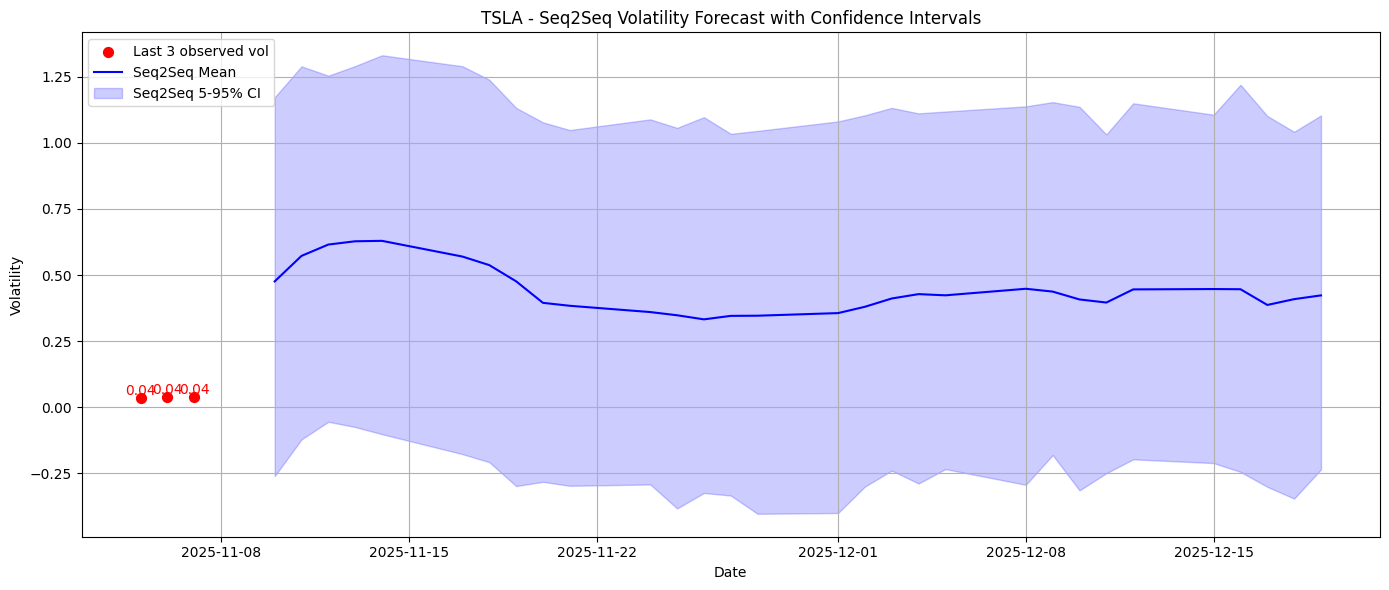

In [26]:
# Calcular volatilidade histórica real (ex: rolling window 10 dias dos log-retornos)
vol_true = df[f'{TICKER}_lr'].rolling(10).std().dropna().values

# Ajustar o tamanho para comparação com HORIZON
y_true_vol = vol_true[-HORIZON:]  # últimos HORIZON dias


# Autoregressive Volatility Forecast
enc_input_last_vol = X_scaled[-SEQ_LEN:].reshape(1, SEQ_LEN, n_features)
states_value_vol = encoder_model_vol_inf.predict(enc_input_last_vol, verbose=0)
last_obs_vol = vol_scaled[-1].reshape(1,1)

pred_scaled_vol = []
current_h_vol, current_c_vol = states_value_vol[0], states_value_vol[1]

for t in range(HORIZON):
    dec_in_t_vol = last_obs_vol.reshape(1,1,1)
    out_token_vol, h_vol, c_vol = decoder_model_vol_inf.predict([dec_in_t_vol, current_h_vol, current_c_vol], verbose=0)
    next_vol_scaled = float(out_token_vol[0,0,0])
    pred_scaled_vol.append(next_vol_scaled)
    last_obs_vol = np.array([[next_vol_scaled]])
    current_h_vol, current_c_vol = h_vol, c_vol

pred_vol_seq2seq = scaler_vol.inverse_transform(np.array(pred_scaled_vol).reshape(-1,1)).flatten()


# 2) Metrics Calculation
def calc_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true==0, 1e-8, y_true))) * 100
    return rmse, mae, mape

y_true_vol = vol_true[-HORIZON:]  # actual volatility for comparison
rmse_vol, mae_vol, mape_vol = calc_metrics(y_true_vol, pred_vol_seq2seq)

print(f"📊 Volatility Forecast Metrics (last {HORIZON} steps):")
print(f"RMSE: {rmse_vol:.4f}, MAE: {mae_vol:.4f}, MAPE: {mape_vol:.2f}%")


# Monte Carlo Confidence Intervals
np.random.seed(42)
N_SIM = 500
S0_vol = vol_scaled[-1]

def monte_carlo_vol(pred_scaled, S0, N_SIM):
    paths = np.zeros((HORIZON, N_SIM))
    for i in range(N_SIM):
        vol = S0
        for t in range(HORIZON):
            vol = pred_scaled[t] + np.random.normal(0, np.std(vol_scaled[-10:]))
            paths[t, i] = vol
    return paths

mc_vol_paths = monte_carlo_vol(pred_scaled_vol, S0_vol, N_SIM)
vol_mean = mc_vol_paths.mean(axis=1)
vol_5 = np.percentile(mc_vol_paths, 5, axis=1)
vol_95 = np.percentile(mc_vol_paths, 95, axis=1)

# Visualization
plt.figure(figsize=(14,6))
dates_future = pd.date_range(start=df.index[-1]+pd.Timedelta(days=1), periods=HORIZON, freq='B')

# Last observed volatility
plt.scatter(df.index[-3:], vol_true[-3:], color='red', s=50, label="Last 3 observed vol")
for d, v in zip(df.index[-3:], vol_true[-3:]):
    plt.text(d, v, f"{v:.2f}", fontsize=10, ha='center', va='bottom', color="red")

# Predicted volatility
plt.plot(dates_future, vol_mean, color='blue', linestyle='-', label="Seq2Seq Mean")
plt.fill_between(dates_future, vol_5, vol_95, color='blue', alpha=0.2, label="Seq2Seq 5-95% CI")

plt.title(f"{TICKER} - Seq2Seq Volatility Forecast with Confidence Intervals")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## 🔹 Prophet Volatility Forecast

This block generates volatility forecasts using the Prophet model. 
It fits Prophet on historical volatility data, creates a future dataframe 
for the prediction horizon, and extracts the predicted volatility values.


In [27]:
# Prophet Volatility
prop_vol_preds = None
if Prophet is not None:
    df_prop_vol = pd.DataFrame({"ds": df.index, "y": vol_series})
    mprop_vol = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False)
    mprop_vol.fit(df_prop_vol)
    fut_vol = mprop_vol.make_future_dataframe(periods=HORIZON, freq="B")
    forecast_vol = mprop_vol.predict(fut_vol)
    prop_vol_preds = forecast_vol["yhat"].iloc[-HORIZON:].values


21:30:20 - cmdstanpy - INFO - Chain [1] start processing
21:30:20 - cmdstanpy - INFO - Chain [1] done processing


## 🔹 XGBoost Volatility Forecast

This block generates volatility forecasts using the XGBoost model. 
It creates lag features, rolling mean and standard deviation, and 
trains an XGBoost regressor. The forecast is performed iteratively 
over the prediction horizon using the last observed values.


In [28]:
# ---------- XGBoost Volatility ----------
xgb_vol_preds = None
if xgb is not None:
    df_x_vol = pd.DataFrame({"vol": vol_series})
    for lag in [1,2,3,5,10]:
        df_x_vol[f"lag_{lag}"] = df_x_vol["vol"].shift(lag)
    df_x_vol['rm_5'] = df_x_vol["vol"].rolling(5).mean()
    df_x_vol['std_10'] = df_x_vol["vol"].rolling(10).std()
    df_x_vol['target'] = df_x_vol["vol"].shift(-1)
    df_x_vol.dropna(inplace=True)
    
    feat_cols_vol = [c for c in df_x_vol.columns if c not in ["target","vol"]]
    Xx_vol, yx_vol = df_x_vol[feat_cols_vol].values, df_x_vol["target"].values
    
    split_vol = int(0.8*len(Xx_vol))
    X_tr_vol, X_te_vol = Xx_vol[:split_vol], Xx_vol[split_vol:]
    y_tr_vol, y_te_vol = yx_vol[:split_vol], yx_vol[split_vol:]
    
    reg_vol = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, tree_method="hist")
    reg_vol.fit(X_tr_vol, y_tr_vol)
    
    tail_vol = vol_series.tolist()
    xgb_vol_preds = []
    for _ in range(HORIZON):
        vals = {f"lag_{lag}": tail_vol[-lag] for lag in [1,2,3,5,10]}
        vals['rm_5'] = np.mean(tail_vol[-5:])
        vals['std_10'] = np.std(tail_vol[-10:])
        feat_vec = np.array([vals[c] for c in feat_cols_vol]).reshape(1,-1)
        p = float(reg_vol.predict(feat_vec)[0])
        xgb_vol_preds.append(p)
        tail_vol.append(p)


## 🔹 Final Volatility Forecast DataFrame

This block creates a consolidated DataFrame containing the volatility forecasts 
from Seq2Seq, Prophet, and XGBoost models for the prediction horizon. 
It rounds values for readability and displays the first 10 rows of the forecast.


In [29]:
# Final volatility forecast DataFrame
df_vol_compare = pd.DataFrame({
    "Date": future_dates,
    "Seq2Seq_vol": pred_vol_seq2seq,
    "Prophet_vol": prop_vol_preds if prop_vol_preds is not None else [np.nan]*HORIZON,
    "XGBoost_vol": xgb_vol_preds if xgb_vol_preds is not None else [np.nan]*HORIZON
})
df_vol_compare = df_vol_compare.round(6)
print("\n📊 Volatility forecast (next HORIZON days):")
print(df_vol_compare.head(10))



📊 Volatility forecast (next HORIZON days):
        Date  Seq2Seq_vol  Prophet_vol  XGBoost_vol
0 2025-11-10     0.042132     0.039135     0.035624
1 2025-11-11     0.043400     0.038791     0.037667
2 2025-11-12     0.044105     0.039001     0.036957
3 2025-11-13     0.044291     0.039093     0.037658
4 2025-11-14     0.044041     0.038946     0.035738
5 2025-11-17     0.043480     0.039161     0.035476
6 2025-11-18     0.042746     0.038818     0.030303
7 2025-11-19     0.041966     0.039027     0.032687
8 2025-11-20     0.041253     0.039119     0.033616
9 2025-11-21     0.040683     0.038972     0.033732


## 🔹 Volatility Forecast Visualization

This block generates line charts comparing historical volatility (rolling standard deviation of log-returns) 
with forecasted volatility from Seq2Seq, Prophet, and XGBoost models. 
Two plots are generated: one including recent historical volatility and another showing only the forecasted values.


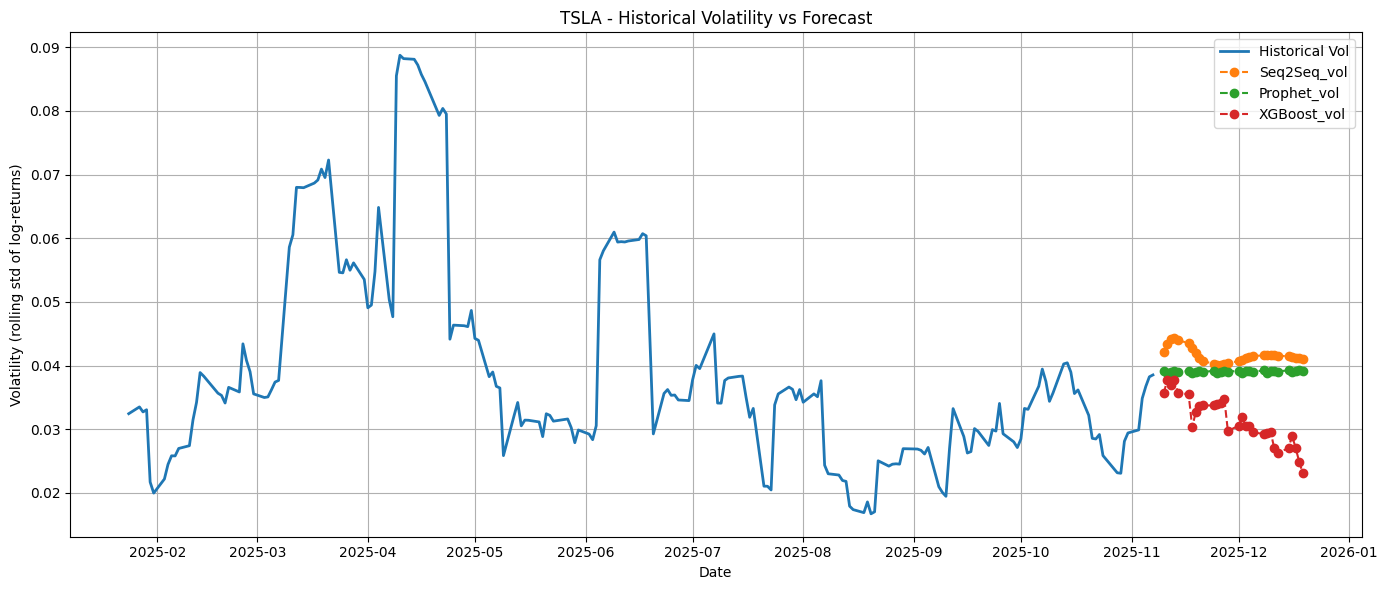

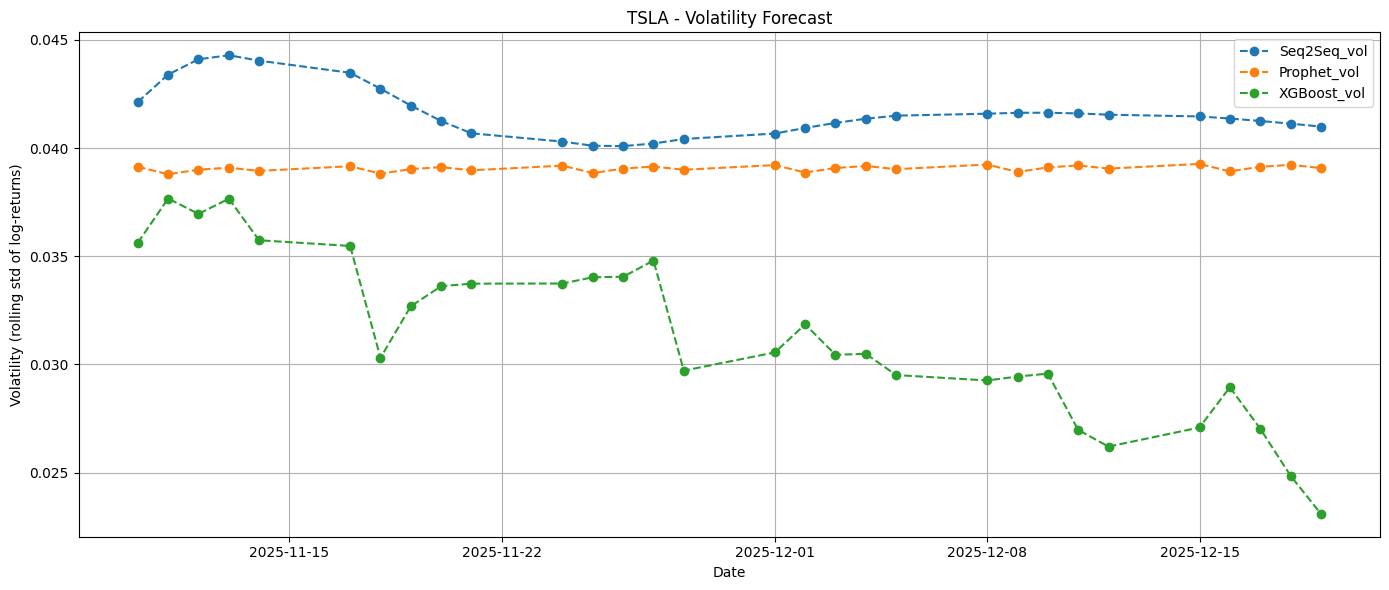

In [30]:
# Volatility plot with historical data
plt.figure(figsize=(14,6))

# Historical volatility
vol_hist = df[f'{TICKER}_lr'].rolling(vol_window).std()
plt.plot(df.index[-200:], vol_hist[-200:], label="Historical Vol", linewidth=2)

# Forecasts
for col in ["Seq2Seq_vol","Prophet_vol","XGBoost_vol"]:
    if col in df_vol_compare.columns:
        plt.plot(df_vol_compare["Date"], df_vol_compare[col], marker='o', linestyle='--', label=col)

plt.title(f"{TICKER} - Historical Volatility vs Forecast")
plt.xlabel("Date")
plt.ylabel("Volatility (rolling std of log-returns)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Volatility forecast only
plt.figure(figsize=(14,6))
for col in ["Seq2Seq_vol","Prophet_vol","XGBoost_vol"]:
    if col in df_vol_compare.columns:
        plt.plot(df_vol_compare["Date"], df_vol_compare[col], marker='o', linestyle='--', label=col)
plt.title(f"{TICKER} - Volatility Forecast")
plt.xlabel("Date")
plt.ylabel("Volatility (rolling std of log-returns)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## 🔹 Seq2Seq Historical Multi-Horizon Forecast

This block performs a historical reconstruction and multi-horizon forecasting using the trained Seq2Seq model.
It predicts 1-day and 3-day ahead prices over the last 350 days in batches. The results are stored for each horizon 
and plotted alongside the actual historical prices to visualize forecast accuracy and temporal trends.


Historical forecast last 350 days: 100%|██████████| 5/5 [00:01<00:00,  3.55it/s]


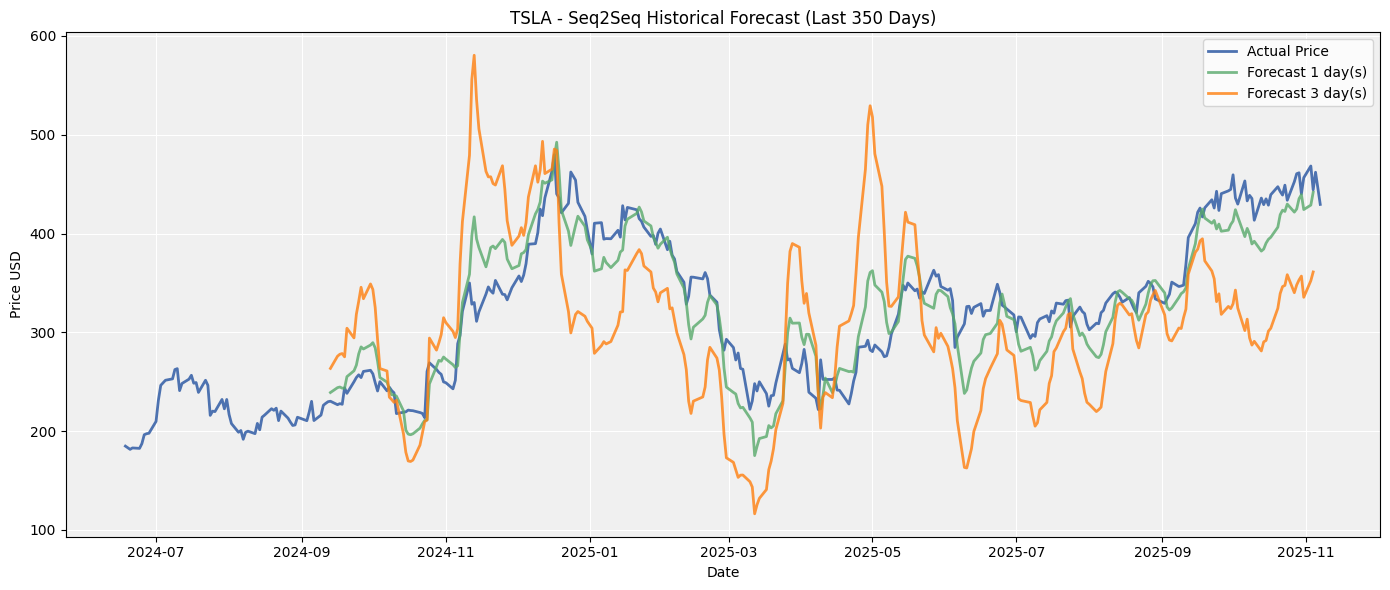

In [32]:
# ----------------- Select historical data -----------------
TICKER_PRICE_COL = f'{TICKER}_price'
df_hist = df.iloc[-SEQ_TO_USE:].copy()
X_scaled_hist = X_scaled[-SEQ_TO_USE:]
y_scaled_hist = y_scaled[-SEQ_TO_USE:]
N_total = len(df_hist) - max(HORIZONS_TO_PLOT)

# ----------------- Initialize dictionaries -----------------
preds_dict = {h: [] for h in HORIZONS_TO_PLOT}
dates_dict = {h: [] for h in HORIZONS_TO_PLOT}

# ----------------- Historical loop -----------------
for start_idx in tqdm(range(SEQ_LEN, N_total, batch_size), desc="Historical forecast last 350 days"):
    end_idx = min(start_idx + batch_size, N_total)
    batch_size_real = end_idx - start_idx

    # Prepare batch encoder input
    enc_batch = np.array([X_scaled_hist[i-SEQ_LEN:i] for i in range(start_idx, end_idx)])
    states_batch = encoder_model_inf.predict(enc_batch, verbose=0)

    # Last observed returns for each sequence in batch
    last_obs_batch = np.array([y_scaled_hist[i-1].reshape(1,1) for i in range(start_idx, end_idx)])

    # Iterative forecast for batch
    batch_preds = np.zeros((batch_size_real, max(HORIZONS_TO_PLOT)))
    for t in range(max(HORIZONS_TO_PLOT)):
        dec_in_batch = last_obs_batch.reshape(batch_size_real, 1, 1)
        out_tokens, h, c = decoder_model_inf.predict([dec_in_batch, states_batch[0], states_batch[1]], verbose=0)
        next_scaled = out_tokens[:,0,0]
        batch_preds[:,t] = next_scaled
        last_obs_batch = next_scaled.reshape(batch_size_real,1,1)
        states_batch = [h, c]

    # Convert log-returns to prices and store
    for i, idx in enumerate(range(start_idx, end_idx)):
        last_price = df_hist[TICKER_PRICE_COL].iloc[idx-1]
        price_pred = []
        price = last_price
        for lr in batch_preds[i]:
            price = price * np.exp(lr)
            price_pred.append(price)
        for h in HORIZONS_TO_PLOT:
            preds_dict[h].append(price_pred[h-1])
            dates_dict[h].append(df_hist.index[idx+h-1])

# ----------------- Fill NaNs at the beginning -----------------
for h in HORIZONS_TO_PLOT:
    missing = SEQ_LEN  # first SEQ_LEN days have no forecast
    preds_dict[h] = [np.nan]*missing + preds_dict[h]
    dates_dict[h] = df_hist.index[:len(preds_dict[h])]

# ----------------- Plot -----------------
plt.figure(figsize=(14,6))
plt.plot(df_hist[TICKER_PRICE_COL], label="Actual Price", color='#4d72b0', linewidth=2)

colors = ["#58a96b", "#ff7f0e"]
for idx, h in enumerate(HORIZONS_TO_PLOT):
    plt.plot(dates_dict[h], preds_dict[h], label=f"Forecast {h} day(s)", 
             color=colors[idx], alpha=0.8, linewidth=2)

plt.gca().set_facecolor('#f0f0f0')  # light gray background
plt.grid(True, color='white')        # white grid
plt.title(f"{TICKER} - Seq2Seq Historical Forecast (Last {SEQ_TO_USE} Days)")
plt.xlabel("Date")
plt.ylabel("Price USD")
plt.legend()
plt.tight_layout()
plt.show()
